# Importações

In [49]:
!pip install xgboost

In [50]:
import pandas as pd
from pathlib import Path
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from xgboost import XGBRegressor

# Base

In [2]:
base_path = Path('data/processed/base_final.parquet')
if not base_path.exists():
    base_path = Path('base_final.parquet')

base = pd.read_parquet(base_path)

In [3]:
base.head()

,subsystem_code,timestamp,load_mw,source_year,precipitation_mm,pressure_station_hpa,pressure_max_hpa,pressure_min_hpa,global_radiation_kj_m2,temperature_c,...,load_mean_3h,load_std_3h,load_mean_6h,load_std_6h,load_mean_24h,load_std_24h,ramp_1h,target_load_1h,target_load_6h,target_load_24h
0,NE,2022-01-08 00:00:00,11926.333,2022,0.520000,974.148148,974.203704,973.448148,47.800000,24.492593,...,12420.102000,134.929127,12237.736833,221.810606,11584.597667,583.661108,-244.169,11635.094,9793.342,11660.956
1,NE,2022-01-08 01:00:00,11635.094,2022,0.253333,973.319643,973.403571,972.975000,1.060000,24.185714,...,12233.397333,292.610669,12222.878833,241.764288,11583.075958,582.678831,-338.512,11402.214,9865.790,11290.670
2,NE,2022-01-08 02:00:00,11402.214,2022,0.238298,974.063793,974.348276,973.979310,16.883333,24.013793,...,11942.090667,315.171078,12139.194667,343.039821,11584.575750,582.768185,-291.239,11147.334,10122.028,11049.698
3,NE,2022-01-08 03:00:00,11147.334,2022,0.486957,973.198214,973.580357,973.164286,615.487500,23.726786,...,11654.547000,262.600449,12037.324500,459.007934,11585.088542,582.594832,-232.880,10927.972,10205.706,10924.900
4,NE,2022-01-08 04:00:00,10927.972,2022,0.195652,973.167273,973.587273,973.147273,426.871429,23.521818,...,11394.880667,243.962677,11814.139000,518.641087,11581.656042,585.017287,-254.880,10275.910,10321.871,10726.672


## Divisão da base

In [4]:
n = len(base)
print(f"Number of rows: {n}")

Number of rows: 40704


In [5]:
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train = base.iloc[:train_end]
val   = base.iloc[train_end:val_end]
test  = base.iloc[val_end:]

print(len(train), len(val), len(test))

28492 6106 6106


In [6]:
print("Inicio e fim do conjunto de treino:", train['timestamp'].min(), train['timestamp'].max())
print("Inicio e fim do conjunto de validação:", val['timestamp'].min(), val['timestamp'].max())
print("Inicio e fim do conjunto de teste:", test['timestamp'].min(), test['timestamp'].max())

Inicio e fim do conjunto de treino: 2022-01-08 00:00:00 2025-04-09 03:00:00
Inicio e fim do conjunto de validação: 2025-04-09 04:00:00 2025-12-19 13:00:00
Inicio e fim do conjunto de teste: 2025-12-19 14:00:00 2026-08-30 23:00:00


In [54]:
features_1 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national'
]

features_2 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw'
]

features_3 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h'
]

features_4 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h',
    'load_mean_3h',
    'load_mean_6h',
    'load_mean_24h',

    'load_std_3h',
    'load_std_6h',
    'load_std_24h',

    'ramp_1h'
]

features_5 = [
    'hour_sin',
        'hour_cos',
        'weekday_sin',
        'weekday_cos',
        'month_sin',
        'month_cos',
        'weekend',
        'is_holiday_national',
        'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h',
        'load_mean_3h',
        'load_mean_6h',
        'load_mean_24h',

        'load_std_3h',
        'load_std_6h',
        'load_std_24h',

        'ramp_1h',
        'precipitation_mm', 'pressure_station_hpa', 'global_radiation_kj_m2', 'temperature_c', 'humidity_pct', 'wind_gust_ms', 'wind_speed_ms'
]

target_1 = 'target_load_1h'
target_6 = 'target_load_6h'
target_24 = 'target_load_24h'

# Linear Regression

## 1h

In [7]:
lista = base.columns.tolist()
print("Colunas do dataset:", lista)

Colunas do dataset: ['subsystem_code', 'timestamp', 'load_mw', 'source_year', 'precipitation_mm', 'pressure_station_hpa', 'pressure_max_hpa', 'pressure_min_hpa', 'global_radiation_kj_m2', 'temperature_c', 'dew_point_c', 'temperature_max_c', 'temperature_min_c', 'dew_point_max_c', 'dew_point_min_c', 'humidity_max_pct', 'humidity_min_pct', 'humidity_pct', 'wind_gust_ms', 'wind_speed_ms', 'wind_direction_deg', 'station_count', 'month', 'weekday', 'weekend', 'hour', 'weekday_num', 'is_holiday_national', 'states_on_holiday', 'hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h', 'load_mean_3h', 'load_std_3h', 'load_mean_6h', 'load_std_6h', 'load_mean_24h', 'load_std_24h', 'ramp_1h', 'target_load_1h', 'target_load_6h', 'target_load_24h']


In [8]:
features_1 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national'
]

features_2 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw'
]

features_3 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h'
]

features_4 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h',
    'load_mean_3h',
    'load_mean_6h',
    'load_mean_24h',

    'load_std_3h',
    'load_std_6h',
    'load_std_24h',

    'ramp_1h'
]

features_5 = [
    'hour_sin',
        'hour_cos',
        'weekday_sin',
        'weekday_cos',
        'month_sin',
        'month_cos',
        'weekend',
        'is_holiday_national',
        'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h',
        'load_mean_3h',
        'load_mean_6h',
        'load_mean_24h',

        'load_std_3h',
        'load_std_6h',
        'load_std_24h',

        'ramp_1h',
        'precipitation_mm', 'pressure_station_hpa', 'global_radiation_kj_m2', 'temperature_c', 'humidity_pct', 'wind_gust_ms', 'wind_speed_ms'
]

target = 'target_load_1h'

In [9]:
def avaliar_modelo(features, nome):

    X_train = train[features]
    y_train = train['target_load_1h']

    X_val = val[features]
    y_val = val['target_load_1h']

    model = LinearRegression()

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, pred)

    rmse = np.sqrt(
        mean_squared_error(y_val, pred)
    )

    mape = mean_absolute_percentage_error(
        y_val,
        pred
    ) * 100

    print(
        f'{nome:<25} | '
        f'MAE: {mae:.2f} | '
        f'RMSE: {rmse:.2f} | '
        f'MAPE: {mape:.2f}%'
    )

    return model

In [10]:
model_1 = avaliar_modelo(
    features_1,
    'Linear - Calendário'
)

model_2 = avaliar_modelo(
    features_2,
    'Linear - + Carga'
)

model_3 = avaliar_modelo(
    features_3,
    'Linear - + Lags'
)

model_4 = avaliar_modelo(
    features_4,
    'Linear - + Rolling'
)

model_5 = avaliar_modelo(
    features_5,
    'Linear - + Meteorologia'
)

Linear - Calendário       | MAE: 1099.95 | RMSE: 1296.59 | MAPE: 8.19%
Linear - + Carga          | MAE: 229.93 | RMSE: 316.45 | MAPE: 1.76%
Linear - + Lags           | MAE: 213.96 | RMSE: 287.53 | MAPE: 1.63%
Linear - + Rolling        | MAE: 207.72 | RMSE: 273.10 | MAPE: 1.59%
Linear - + Meteorologia   | MAE: 204.85 | RMSE: 268.27 | MAPE: 1.57%


In [11]:
X_train = train[features_5]
y_train = train['target_load_1h']

model_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

model_scaled.fit(X_train, y_train)

coef = model_scaled.named_steps['regressor'].coef_

coeficientes = pd.DataFrame({
    'feature': features_5,
    'coeficiente': coef
})

coeficientes['abs_coef'] = coeficientes['coeficiente'].abs()

coeficientes = coeficientes.sort_values(
    'abs_coef',
    ascending=False
)

print(coeficientes)

                   feature  coeficiente     abs_coef
8                  load_mw  1974.690790  1974.690790
16            load_mean_6h  -279.690530   279.690530
17           load_mean_24h   275.959212   275.959212
27            wind_gust_ms   242.340494   242.340494
28           wind_speed_ms  -213.286054   213.286054
9              load_lag_1h  -169.999301   169.999301
21                 ramp_1h  -161.562029   161.562029
10             load_lag_2h  -130.618272   130.618272
15            load_mean_3h  -119.023132   119.023132
12            load_lag_24h   -82.042719    82.042719
6                  weekend   -57.967197    57.967197
24  global_radiation_kj_m2   -53.644651    53.644651
11             load_lag_3h   -50.545686    50.545686
25           temperature_c    49.346987    49.346987
1                 hour_cos   -47.900617    47.900617
26            humidity_pct   -37.931743    37.931743
20            load_std_24h    34.992755    34.992755
19             load_std_6h   -29.995972    29.

In [12]:
# Resíduos na validação: valor observado menos valor previsto (MW).
X_val_scaled = val[features_5]
pred_val_scaled = model_scaled.predict(X_val_scaled)

residuos_scaled = pd.DataFrame({
    'timestamp': val['timestamp'],
    'observado': val[target],
    'previsto': pred_val_scaled,
}, index=val.index)
residuos_scaled['residuo'] = (
    residuos_scaled['observado'] - residuos_scaled['previsto']
)

residuos_scaled.head()


,timestamp,observado,previsto,residuo
28492,2025-04-09 04:00:00,13268.071,13430.463950,-162.392950
28493,2025-04-09 05:00:00,12893.804,13137.337228,-243.533228
28494,2025-04-09 06:00:00,13391.710,12897.483528,494.226472
28495,2025-04-09 07:00:00,14051.591,13703.599700,347.991300
28496,2025-04-09 08:00:00,14175.506,14222.991874,-47.485874


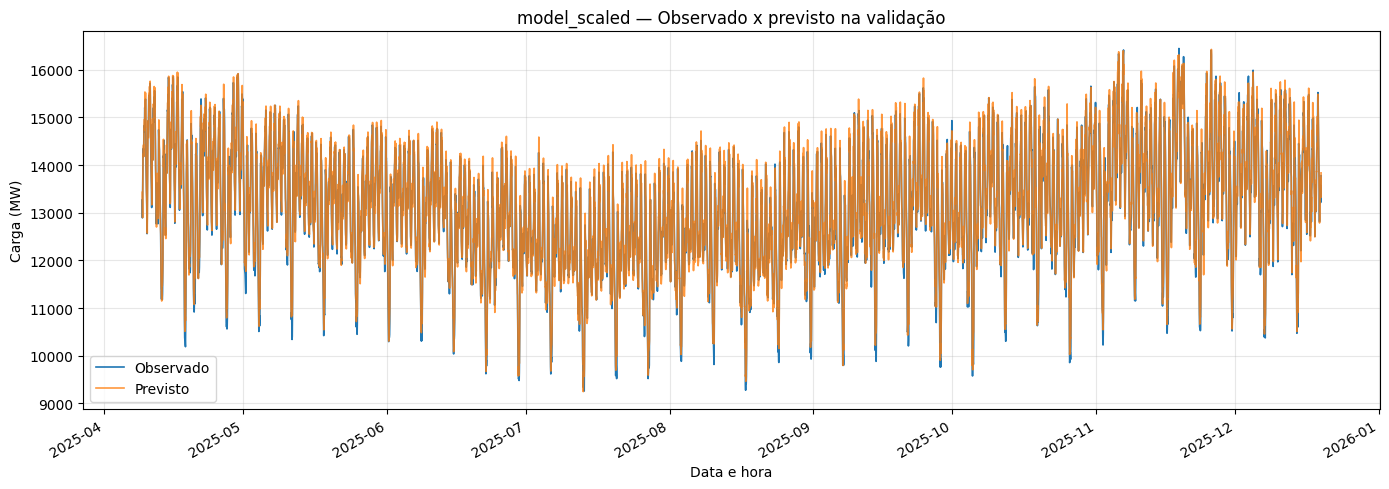

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    residuos_scaled['timestamp'], residuos_scaled['observado'],
    label='Observado', linewidth=1.2,
)
ax.plot(
    residuos_scaled['timestamp'], residuos_scaled['previsto'],
    label='Previsto', linewidth=1.2, alpha=0.8,
)
ax.set_title('model_scaled — Observado x previsto na validação')
ax.set_xlabel('Data e hora')
ax.set_ylabel('Carga (MW)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


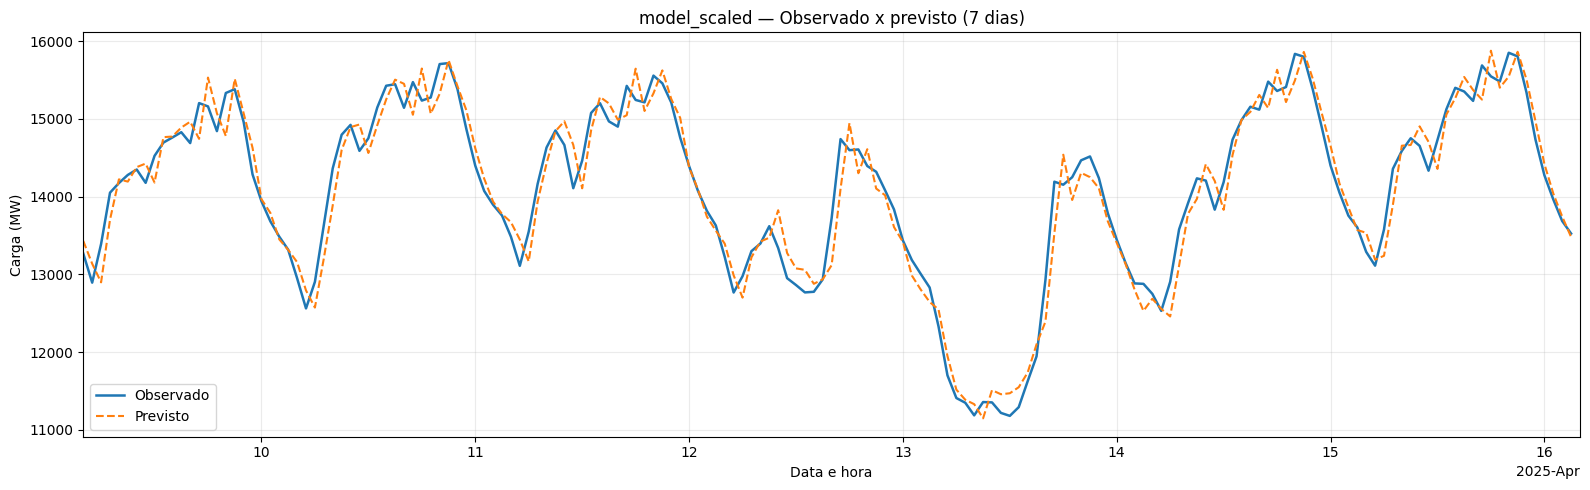

In [14]:
inicio_plot = pd.to_datetime(residuos_scaled['timestamp']).min()
dias_plot = 7
fim_plot = inicio_plot + pd.Timedelta(days=dias_plot)

dados_plot = residuos_scaled.copy()
dados_plot['timestamp'] = pd.to_datetime(dados_plot['timestamp'])
dados_plot = dados_plot.loc[
    (dados_plot['timestamp'] >= inicio_plot)
    & (dados_plot['timestamp'] < fim_plot)
].sort_values('timestamp')

if dados_plot.empty:
    raise ValueError('Não há dados no período selecionado. Ajuste inicio_plot ou dias_plot.')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(
    dados_plot['timestamp'], dados_plot['observado'],
    label='Observado', color='tab:blue', linewidth=1.8,
)
ax.plot(
    dados_plot['timestamp'], dados_plot['previsto'],
    label='Previsto', color='tab:orange', linewidth=1.5, linestyle='--',
)

limite_inferior = dados_plot[['observado', 'previsto']].min().min()
limite_superior = dados_plot[['observado', 'previsto']].max().max()
margem = max((limite_superior - limite_inferior) * 0.05, 1.0)
ax.set_ylim(limite_inferior - margem, limite_superior + margem)
ax.set_xlim(inicio_plot, fim_plot)
localizador = mdates.AutoDateLocator(minticks=5, maxticks=10)
ax.xaxis.set_major_locator(localizador)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(localizador))
ax.ticklabel_format(axis='y', style='plain', useOffset=False)
ax.set_title(f'model_scaled — Observado x previsto ({dias_plot} dias)')
ax.set_xlabel('Data e hora')
ax.set_ylabel('Carga (MW)')
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()


Horários com maior erro absoluto médio (MAE), em toda a validação:
Hora da carga prevista (t + 1h), conforme o relógio da base.
Viés positivo: previsão abaixo do observado; negativo: acima.


,quantidade,mae_mw,rmse_mw,vies_mw,maior_erro_absoluto_mw
hora,,,,,
12,255,431.71,453.99,-423.39,811.05
19,254,397.92,425.75,-396.59,964.62
18,254,372.13,424.72,366.26,1210.35
17,254,329.49,424.85,105.31,1260.47
21,254,292.25,335.00,280.38,874.37
7,255,280.08,338.52,143.13,1094.37
13,255,252.73,298.17,37.61,931.24
8,255,248.07,303.56,107.56,899.11
16,254,202.05,254.77,140.66,1126.44


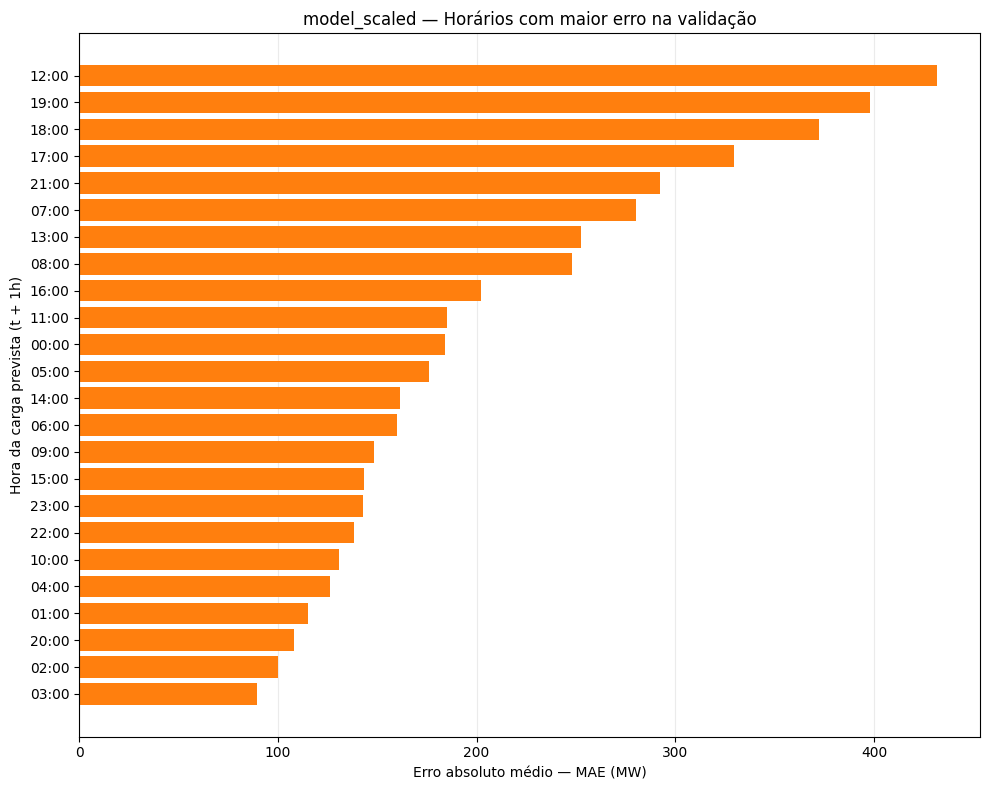

In [15]:
import matplotlib.pyplot as plt
from IPython.display import display

# Avalia toda a validação, agrupando pela hora da carga prevista (t + 1h).
erros_horarios_scaled = residuos_scaled.copy()
erros_horarios_scaled['hora'] = (
    pd.to_datetime(erros_horarios_scaled['timestamp']) + pd.Timedelta(hours=1)
).dt.hour
erros_horarios_scaled = erros_horarios_scaled.dropna(subset=['hora', 'residuo'])
erros_horarios_scaled['erro_absoluto'] = erros_horarios_scaled['residuo'].abs()
erros_horarios_scaled['erro_quadrado'] = erros_horarios_scaled['residuo'] ** 2

ranking_horarios_scaled = (
    erros_horarios_scaled.groupby('hora')
    .agg(
        quantidade=('residuo', 'count'),
        mae_mw=('erro_absoluto', 'mean'),
        mse_mw2=('erro_quadrado', 'mean'),
        vies_mw=('residuo', 'mean'),
        maior_erro_absoluto_mw=('erro_absoluto', 'max'),
    )
    .assign(rmse_mw=lambda tabela: np.sqrt(tabela['mse_mw2']))
    .drop(columns='mse_mw2')
    .sort_values(['mae_mw', 'hora'], ascending=[False, True])
)
ranking_horarios_scaled = ranking_horarios_scaled[
    ['quantidade', 'mae_mw', 'rmse_mw', 'vies_mw', 'maior_erro_absoluto_mw']
]

print('Horários com maior erro absoluto médio (MAE), em toda a validação:')
print('Hora da carga prevista (t + 1h), conforme o relógio da base.')
print('Viés positivo: previsão abaixo do observado; negativo: acima.')
display(ranking_horarios_scaled.round(2))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    [f'{int(hora):02d}:00' for hora in ranking_horarios_scaled.index],
    ranking_horarios_scaled['mae_mw'],
    color='tab:orange',
)
ax.invert_yaxis()
ax.set_title('model_scaled — Horários com maior erro na validação')
ax.set_xlabel('Erro absoluto médio — MAE (MW)')
ax.set_ylabel('Hora da carga prevista (t + 1h)')
ax.grid(axis='x', alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()


## 6h

In [16]:
features_1 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national'
]

features_2 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw'
]

features_3 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h'
]

features_4 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h',
    'load_mean_3h',
    'load_mean_6h',
    'load_mean_24h',

    'load_std_3h',
    'load_std_6h',
    'load_std_24h',

    'ramp_1h'
]

features_5 = [
    'hour_sin',
        'hour_cos',
        'weekday_sin',
        'weekday_cos',
        'month_sin',
        'month_cos',
        'weekend',
        'is_holiday_national',
        'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h',
        'load_mean_3h',
        'load_mean_6h',
        'load_mean_24h',

        'load_std_3h',
        'load_std_6h',
        'load_std_24h',

        'ramp_1h',
        'precipitation_mm', 'pressure_station_hpa', 'global_radiation_kj_m2', 'temperature_c', 'humidity_pct', 'wind_gust_ms', 'wind_speed_ms'
]

target = 'target_load_6h'

In [17]:
def avaliar_modelo(features, nome):

    X_train = train[features]
    y_train = train['target_load_6h']

    X_val = val[features]
    y_val = val['target_load_6h']

    model = LinearRegression()

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, pred)

    rmse = np.sqrt(
        mean_squared_error(y_val, pred)
    )

    mape = mean_absolute_percentage_error(
        y_val,
        pred
    ) * 100

    print(
        f'{nome:<25} | '
        f'MAE: {mae:.2f} | '
        f'RMSE: {rmse:.2f} | '
        f'MAPE: {mape:.2f}%'
    )

    return model

In [18]:
model_6h_1 = avaliar_modelo(
    features_1,
    'Linear - Calendário'
)

model_6h_2 = avaliar_modelo(
    features_2,
    'Linear - + Carga'
)

model_6h_3 = avaliar_modelo(
    features_3,
    'Linear - + Lags'
)

model_6h_4 = avaliar_modelo(
    features_4,
    'Linear - + Rolling'
)

model_6h_5 = avaliar_modelo(
    features_5,
    'Linear - + Meteorologia'
)

Linear - Calendário       | MAE: 1092.91 | RMSE: 1285.68 | MAPE: 8.14%
Linear - + Carga          | MAE: 622.07 | RMSE: 827.06 | MAPE: 4.75%
Linear - + Lags           | MAE: 613.97 | RMSE: 795.62 | MAPE: 4.71%
Linear - + Rolling        | MAE: 482.57 | RMSE: 620.31 | MAPE: 3.80%
Linear - + Meteorologia   | MAE: 451.03 | RMSE: 586.75 | MAPE: 3.56%


In [19]:
X_train = train[features_5]
y_train = train['target_load_6h']

model_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

model_scaled.fit(X_train, y_train)

coef = model_scaled.named_steps['regressor'].coef_

coeficientes = pd.DataFrame({
    'feature': features_5,
    'coeficiente': coef
})

coeficientes['abs_coef'] = coeficientes['coeficiente'].abs()

coeficientes = coeficientes.sort_values(
    'abs_coef',
    ascending=False
)

print(coeficientes)

                   feature  coeficiente     abs_coef
17           load_mean_24h  1318.222777  1318.222777
8                  load_mw   928.809194   928.809194
16            load_mean_6h  -672.302300   672.302300
6                  weekend  -423.103573   423.103573
24  global_radiation_kj_m2   382.900651   382.900651
0                 hour_sin   347.911442   347.911442
12            load_lag_24h  -331.156590   331.156590
11             load_lag_3h  -228.492996   228.492996
20            load_std_24h   209.830608   209.830608
25           temperature_c   200.715476   200.715476
27            wind_gust_ms   153.061455   153.061455
7      is_holiday_national  -118.649976   118.649976
13            load_lag_48h   112.805631   112.805631
3              weekday_cos    88.036775    88.036775
28           wind_speed_ms   -87.044545    87.044545
18             load_std_3h   -84.221275    84.221275
15            load_mean_3h   -79.651158    79.651158
2              weekday_sin   -67.568048    67.

In [20]:
# Resíduos na validação: valor observado menos valor previsto (MW).
X_val_scaled = val[features_5]
pred_val_scaled = model_scaled.predict(X_val_scaled)

residuos_scaled = pd.DataFrame({
    'timestamp': val['timestamp'],
    'observado': val[target],
    'previsto': pred_val_scaled,
}, index=val.index)
residuos_scaled['residuo'] = (
    residuos_scaled['observado'] - residuos_scaled['previsto']
)

residuos_scaled.head()


,timestamp,observado,previsto,residuo
28492,2025-04-09 04:00:00,14280.053,13767.897447,512.155553
28493,2025-04-09 05:00:00,14349.609,13865.480637,484.128363
28494,2025-04-09 06:00:00,14178.355,13886.498143,291.856857
28495,2025-04-09 07:00:00,14525.764,14175.568685,350.195315
28496,2025-04-09 08:00:00,14696.861,14621.272544,75.588456


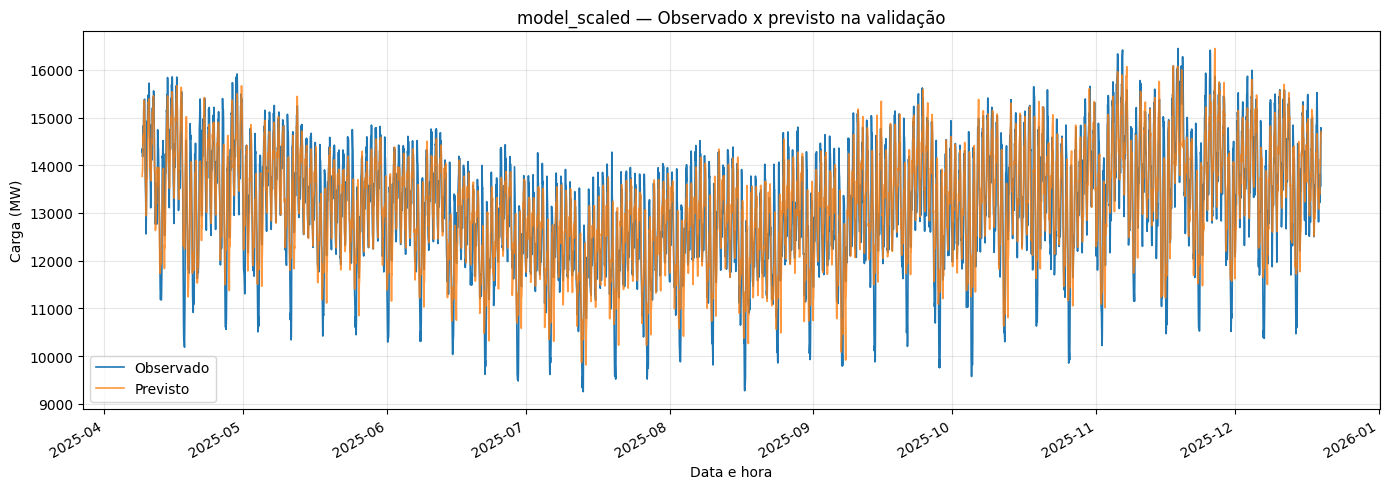

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    residuos_scaled['timestamp'], residuos_scaled['observado'],
    label='Observado', linewidth=1.2,
)
ax.plot(
    residuos_scaled['timestamp'], residuos_scaled['previsto'],
    label='Previsto', linewidth=1.2, alpha=0.8,
)
ax.set_title('model_scaled — Observado x previsto na validação')
ax.set_xlabel('Data e hora')
ax.set_ylabel('Carga (MW)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


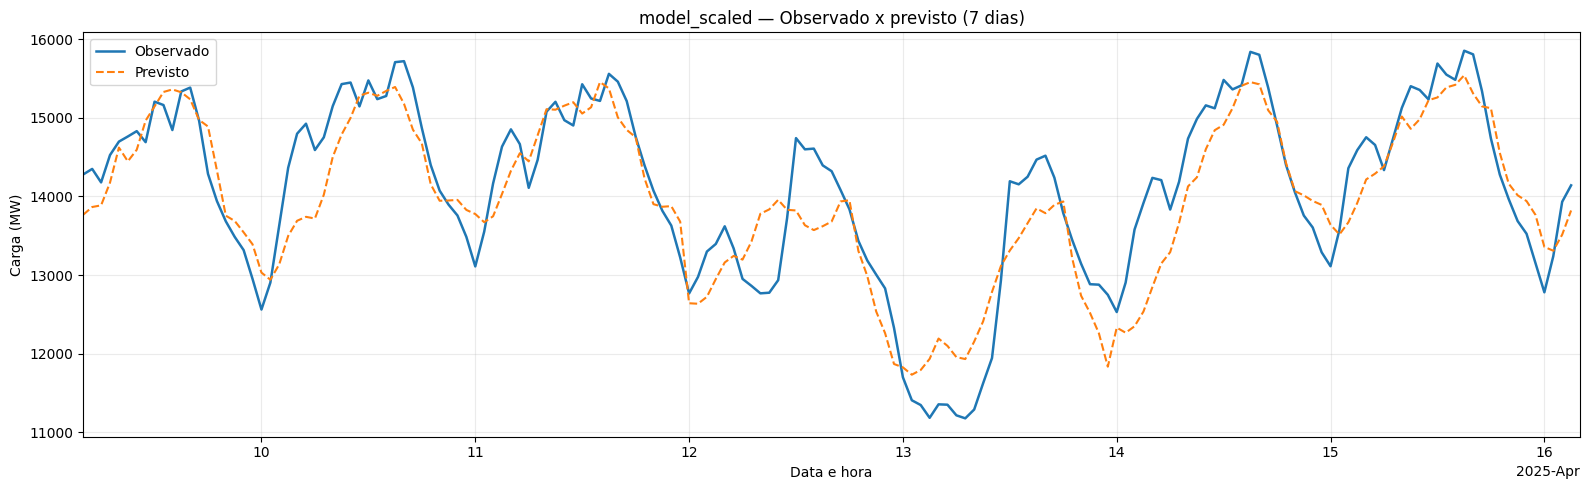

In [22]:
inicio_plot = pd.to_datetime(residuos_scaled['timestamp']).min()
dias_plot = 7
fim_plot = inicio_plot + pd.Timedelta(days=dias_plot)

dados_plot = residuos_scaled.copy()
dados_plot['timestamp'] = pd.to_datetime(dados_plot['timestamp'])
dados_plot = dados_plot.loc[
    (dados_plot['timestamp'] >= inicio_plot)
    & (dados_plot['timestamp'] < fim_plot)
].sort_values('timestamp')

if dados_plot.empty:
    raise ValueError('Não há dados no período selecionado. Ajuste inicio_plot ou dias_plot.')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(
    dados_plot['timestamp'], dados_plot['observado'],
    label='Observado', color='tab:blue', linewidth=1.8,
)
ax.plot(
    dados_plot['timestamp'], dados_plot['previsto'],
    label='Previsto', color='tab:orange', linewidth=1.5, linestyle='--',
)

limite_inferior = dados_plot[['observado', 'previsto']].min().min()
limite_superior = dados_plot[['observado', 'previsto']].max().max()
margem = max((limite_superior - limite_inferior) * 0.05, 1.0)
ax.set_ylim(limite_inferior - margem, limite_superior + margem)
ax.set_xlim(inicio_plot, fim_plot)
localizador = mdates.AutoDateLocator(minticks=5, maxticks=10)
ax.xaxis.set_major_locator(localizador)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(localizador))
ax.ticklabel_format(axis='y', style='plain', useOffset=False)
ax.set_title(f'model_scaled — Observado x previsto ({dias_plot} dias)')
ax.set_xlabel('Data e hora')
ax.set_ylabel('Carga (MW)')
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()


Horários com maior erro absoluto médio (MAE), em toda a validação:
Hora da carga prevista (t + 1h), conforme o relógio da base.
Viés positivo: previsão abaixo do observado; negativo: acima.


,quantidade,mae_mw,rmse_mw,vies_mw,maior_erro_absoluto_mw
hora,,,,,
17,255,734.55,864.59,707.54,2160.87
12,255,699.50,831.95,-632.12,2057.58
11,255,682.87,823.10,-594.37,2143.63
13,255,584.05,716.38,-506.75,1860.90
9,255,556.06,754.08,-102.80,2415.54
8,254,544.44,723.14,15.39,2243.84
10,255,539.02,704.31,-223.87,2364.03
7,254,538.84,661.39,213.31,1859.38
23,254,522.94,611.95,-467.55,1542.09


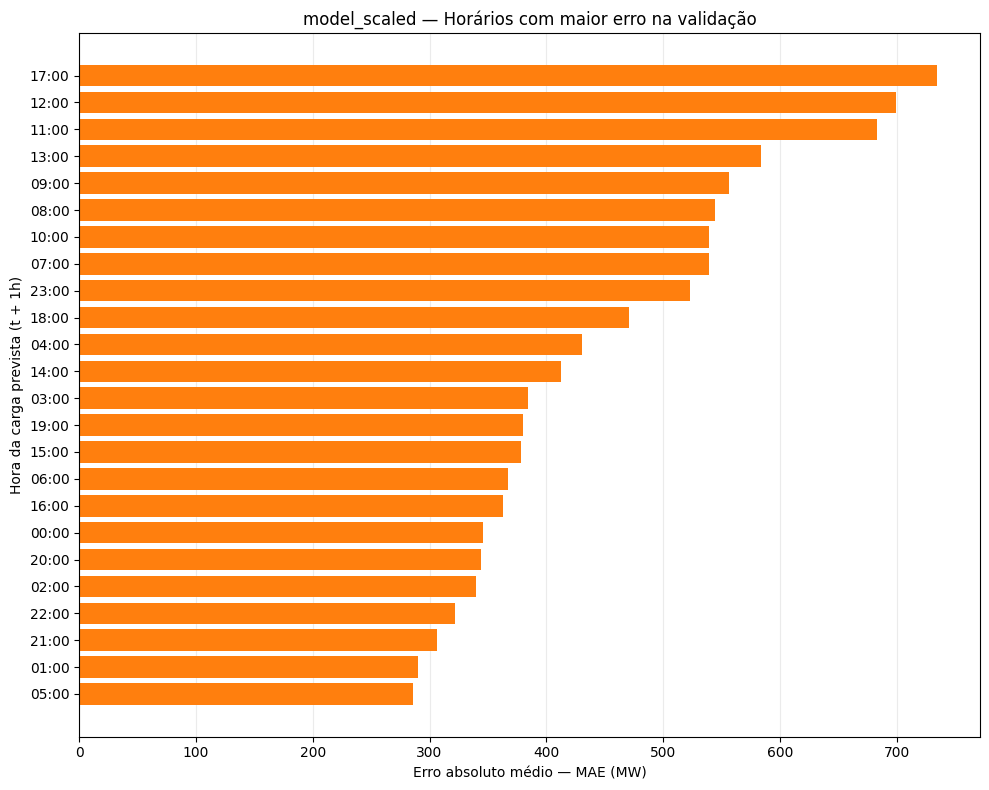

In [23]:
# Avalia toda a validação, agrupando pela hora da carga prevista (t + 1h).
erros_horarios_scaled = residuos_scaled.copy()
erros_horarios_scaled['hora'] = (
    pd.to_datetime(erros_horarios_scaled['timestamp']) + pd.Timedelta(hours=5)
).dt.hour
erros_horarios_scaled = erros_horarios_scaled.dropna(subset=['hora', 'residuo'])
erros_horarios_scaled['erro_absoluto'] = erros_horarios_scaled['residuo'].abs()
erros_horarios_scaled['erro_quadrado'] = erros_horarios_scaled['residuo'] ** 2

ranking_horarios_scaled = (
    erros_horarios_scaled.groupby('hora')
    .agg(
        quantidade=('residuo', 'count'),
        mae_mw=('erro_absoluto', 'mean'),
        mse_mw2=('erro_quadrado', 'mean'),
        vies_mw=('residuo', 'mean'),
        maior_erro_absoluto_mw=('erro_absoluto', 'max'),
    )
    .assign(rmse_mw=lambda tabela: np.sqrt(tabela['mse_mw2']))
    .drop(columns='mse_mw2')
    .sort_values(['mae_mw', 'hora'], ascending=[False, True])
)
ranking_horarios_scaled = ranking_horarios_scaled[
    ['quantidade', 'mae_mw', 'rmse_mw', 'vies_mw', 'maior_erro_absoluto_mw']
]

print('Horários com maior erro absoluto médio (MAE), em toda a validação:')
print('Hora da carga prevista (t + 1h), conforme o relógio da base.')
print('Viés positivo: previsão abaixo do observado; negativo: acima.')
display(ranking_horarios_scaled.round(2))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    [f'{int(hora):02d}:00' for hora in ranking_horarios_scaled.index],
    ranking_horarios_scaled['mae_mw'],
    color='tab:orange',
)
ax.invert_yaxis()
ax.set_title('model_scaled — Horários com maior erro na validação')
ax.set_xlabel('Erro absoluto médio — MAE (MW)')
ax.set_ylabel('Hora da carga prevista (t + 1h)')
ax.grid(axis='x', alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()


## 24h

In [24]:
features_1 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national'
]

features_2 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw'
]

features_3 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h'
]

features_4 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h',
    'load_mean_3h',
    'load_mean_6h',
    'load_mean_24h',

    'load_std_3h',
    'load_std_6h',
    'load_std_24h',

    'ramp_1h'
]

features_5 = [
    'hour_sin',
        'hour_cos',
        'weekday_sin',
        'weekday_cos',
        'month_sin',
        'month_cos',
        'weekend',
        'is_holiday_national',
        'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h',
        'load_mean_3h',
        'load_mean_6h',
        'load_mean_24h',

        'load_std_3h',
        'load_std_6h',
        'load_std_24h',

        'ramp_1h',
        'precipitation_mm', 'pressure_station_hpa', 'global_radiation_kj_m2', 'temperature_c', 'humidity_pct', 'wind_gust_ms', 'wind_speed_ms'
]

target = 'target_load_24h'

In [25]:
def avaliar_modelo(features, nome):

    X_train = train[features]
    y_train = train['target_load_24h']

    X_val = val[features]
    y_val = val['target_load_24h']

    model = LinearRegression()

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, pred)

    rmse = np.sqrt(
        mean_squared_error(y_val, pred)
    )

    mape = mean_absolute_percentage_error(
        y_val,
        pred
    ) * 100

    print(
        f'{nome:<25} | '
        f'MAE: {mae:.2f} | '
        f'RMSE: {rmse:.2f} | '
        f'MAPE: {mape:.2f}%'
    )

    return model

In [26]:
model_24h_1 = avaliar_modelo(
    features_1,
    'Linear - Calendário'
)

model_24h_2 = avaliar_modelo(
    features_2,
    'Linear - + Carga'
)

model_24h_3 = avaliar_modelo(
    features_3,
    'Linear - + Lags'
)

model_24h_4 = avaliar_modelo(
    features_4,
    'Linear - + Rolling'
)

model_24h_5 = avaliar_modelo(
    features_5,
    'Linear - + Meteorologia'
)

Linear - Calendário       | MAE: 1118.43 | RMSE: 1306.26 | MAPE: 8.33%
Linear - + Carga          | MAE: 558.75 | RMSE: 775.76 | MAPE: 4.36%
Linear - + Lags           | MAE: 525.69 | RMSE: 710.27 | MAPE: 4.13%
Linear - + Rolling        | MAE: 493.15 | RMSE: 669.15 | MAPE: 3.91%
Linear - + Meteorologia   | MAE: 490.28 | RMSE: 664.06 | MAPE: 3.88%


In [27]:
X_train = train[features_5]
y_train = train['target_load_24h']

model_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

model_scaled.fit(X_train, y_train)

coef = model_scaled.named_steps['regressor'].coef_

coeficientes = pd.DataFrame({
    'feature': features_5,
    'coeficiente': coef
})

coeficientes['abs_coef'] = coeficientes['coeficiente'].abs()

coeficientes = coeficientes.sort_values(
    'abs_coef',
    ascending=False
)

print(coeficientes)

                   feature  coeficiente    abs_coef
8                  load_mw   747.958800  747.958800
13            load_lag_48h   431.160474  431.160474
17           load_mean_24h   420.022277  420.022277
3              weekday_cos   323.934895  323.934895
16            load_mean_6h  -291.511204  291.511204
2              weekday_sin   281.921847  281.921847
0                 hour_sin  -209.038168  209.038168
12            load_lag_24h  -195.122711  195.122711
11             load_lag_3h   150.408024  150.408024
20            load_std_24h   148.549877  148.549877
25           temperature_c   134.619587  134.619587
1                 hour_cos   134.127639  134.127639
24  global_radiation_kj_m2  -114.788862  114.788862
27            wind_gust_ms  -105.238251  105.238251
14           load_lag_168h    76.686557   76.686557
19             load_std_6h    66.055439   66.055439
23    pressure_station_hpa    63.130133   63.130133
28           wind_speed_ms    57.353826   57.353826
10          

In [28]:
# Resíduos na validação: valor observado menos valor previsto (MW).
X_val_scaled = val[features_5]
pred_val_scaled = model_scaled.predict(X_val_scaled)

residuos_scaled = pd.DataFrame({
    'timestamp': val['timestamp'],
    'observado': val[target],
    'previsto': pred_val_scaled,
}, index=val.index)
residuos_scaled['residuo'] = (
    residuos_scaled['observado'] - residuos_scaled['previsto']
)

residuos_scaled.head()


,timestamp,observado,previsto,residuo
28492,2025-04-09 04:00:00,13317.534,13574.188705,-256.654705
28493,2025-04-09 05:00:00,12950.658,13337.052412,-386.394412
28494,2025-04-09 06:00:00,12561.855,12998.989465,-437.134465
28495,2025-04-09 07:00:00,12904.483,13368.877643,-464.394643
28496,2025-04-09 08:00:00,13637.128,13825.220356,-188.092356


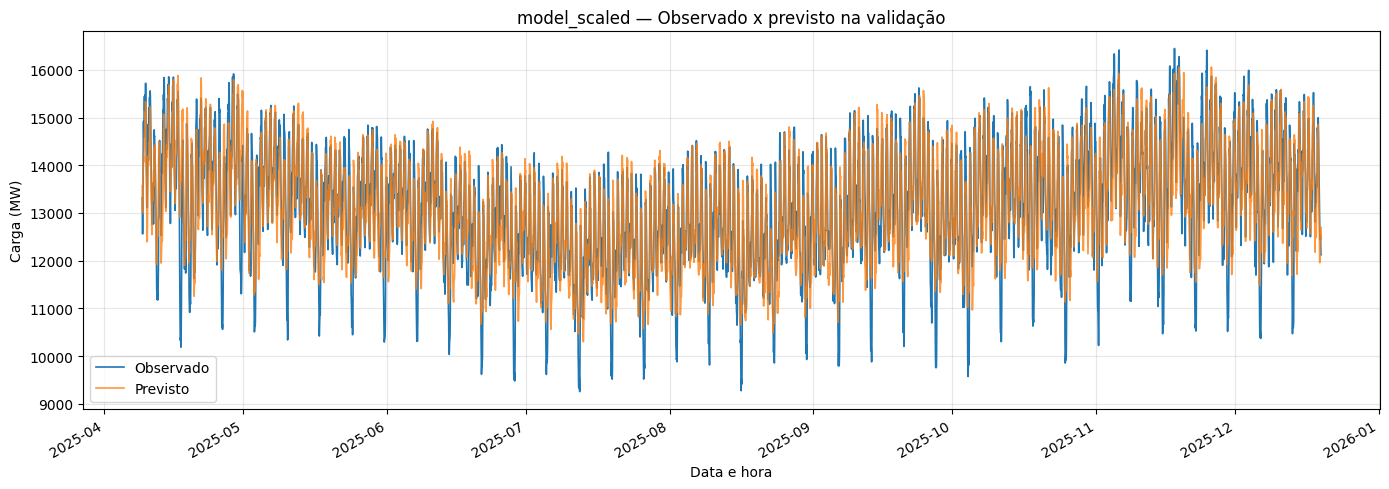

In [29]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    residuos_scaled['timestamp'], residuos_scaled['observado'],
    label='Observado', linewidth=1.2,
)
ax.plot(
    residuos_scaled['timestamp'], residuos_scaled['previsto'],
    label='Previsto', linewidth=1.2, alpha=0.8,
)
ax.set_title('model_scaled — Observado x previsto na validação')
ax.set_xlabel('Data e hora')
ax.set_ylabel('Carga (MW)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


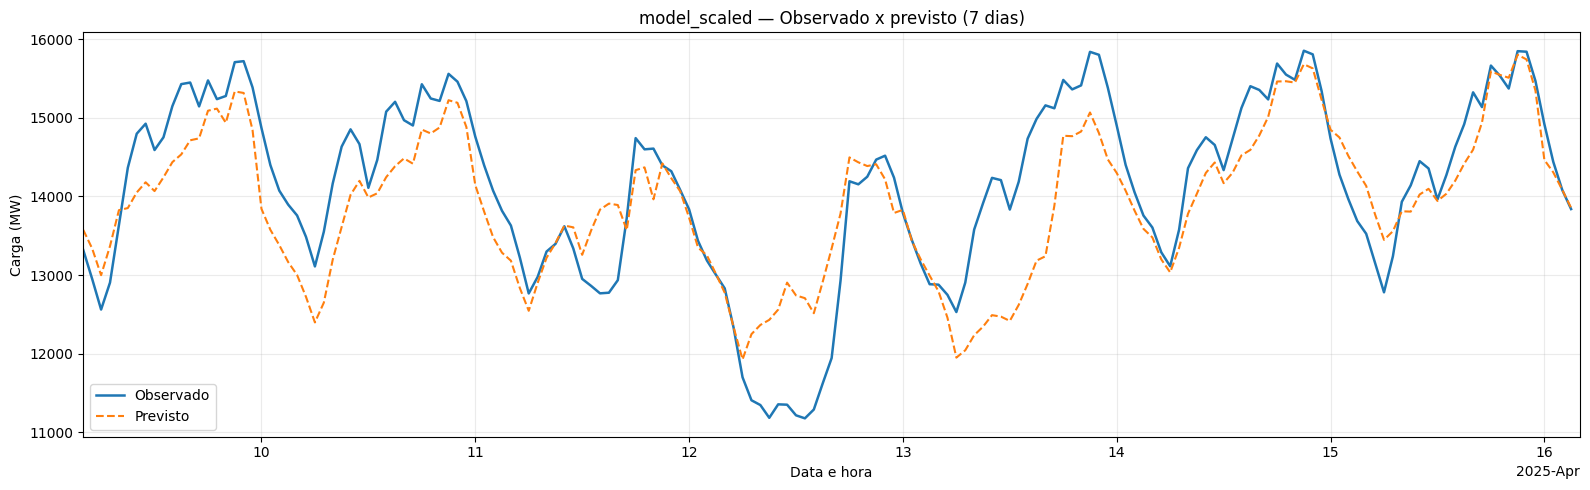

In [30]:
inicio_plot = pd.to_datetime(residuos_scaled['timestamp']).min()
dias_plot = 7
fim_plot = inicio_plot + pd.Timedelta(days=dias_plot)

dados_plot = residuos_scaled.copy()
dados_plot['timestamp'] = pd.to_datetime(dados_plot['timestamp'])
dados_plot = dados_plot.loc[
    (dados_plot['timestamp'] >= inicio_plot)
    & (dados_plot['timestamp'] < fim_plot)
].sort_values('timestamp')

if dados_plot.empty:
    raise ValueError('Não há dados no período selecionado. Ajuste inicio_plot ou dias_plot.')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(
    dados_plot['timestamp'], dados_plot['observado'],
    label='Observado', color='tab:blue', linewidth=1.8,
)
ax.plot(
    dados_plot['timestamp'], dados_plot['previsto'],
    label='Previsto', color='tab:orange', linewidth=1.5, linestyle='--',
)

limite_inferior = dados_plot[['observado', 'previsto']].min().min()
limite_superior = dados_plot[['observado', 'previsto']].max().max()
margem = max((limite_superior - limite_inferior) * 0.05, 1.0)
ax.set_ylim(limite_inferior - margem, limite_superior + margem)
ax.set_xlim(inicio_plot, fim_plot)
localizador = mdates.AutoDateLocator(minticks=5, maxticks=10)
ax.xaxis.set_major_locator(localizador)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(localizador))
ax.ticklabel_format(axis='y', style='plain', useOffset=False)
ax.set_title(f'model_scaled — Observado x previsto ({dias_plot} dias)')
ax.set_xlabel('Data e hora')
ax.set_ylabel('Carga (MW)')
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()


Horários com maior erro absoluto médio (MAE), em toda a validação:
Hora da carga prevista (t + 1h), conforme o relógio da base.
Viés positivo: previsão abaixo do observado; negativo: acima.


,quantidade,mae_mw,rmse_mw,vies_mw,maior_erro_absoluto_mw
hora,,,,,
14,254,803.85,1022.96,-116.22,3557.24
15,254,769.04,968.09,-64.04,3316.14
10,255,764.13,965.74,70.81,3428.59
9,255,755.88,947.70,113.18,3117.67
13,255,718.84,926.97,-137.00,3642.37
11,255,702.01,901.78,-28.60,3432.34
8,255,674.97,846.57,134.27,2728.24
16,254,637.50,804.21,-16.17,3057.19
12,255,624.23,823.24,-149.98,3414.22


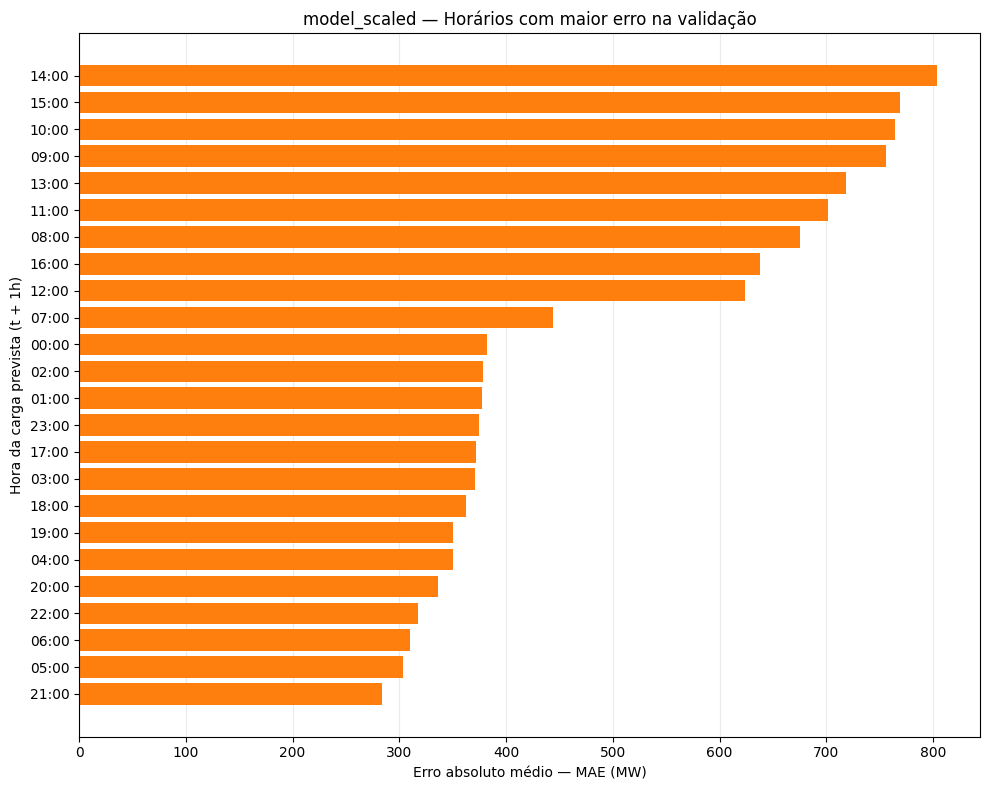

In [31]:
# Avalia toda a validação, agrupando pela hora da carga prevista (t + 1h).
erros_horarios_scaled = residuos_scaled.copy()
erros_horarios_scaled['hora'] = (
    pd.to_datetime(erros_horarios_scaled['timestamp']) + pd.Timedelta(hours=24)
).dt.hour
erros_horarios_scaled = erros_horarios_scaled.dropna(subset=['hora', 'residuo'])
erros_horarios_scaled['erro_absoluto'] = erros_horarios_scaled['residuo'].abs()
erros_horarios_scaled['erro_quadrado'] = erros_horarios_scaled['residuo'] ** 2

ranking_horarios_scaled = (
    erros_horarios_scaled.groupby('hora')
    .agg(
        quantidade=('residuo', 'count'),
        mae_mw=('erro_absoluto', 'mean'),
        mse_mw2=('erro_quadrado', 'mean'),
        vies_mw=('residuo', 'mean'),
        maior_erro_absoluto_mw=('erro_absoluto', 'max'),
    )
    .assign(rmse_mw=lambda tabela: np.sqrt(tabela['mse_mw2']))
    .drop(columns='mse_mw2')
    .sort_values(['mae_mw', 'hora'], ascending=[False, True])
)
ranking_horarios_scaled = ranking_horarios_scaled[
    ['quantidade', 'mae_mw', 'rmse_mw', 'vies_mw', 'maior_erro_absoluto_mw']
]

print('Horários com maior erro absoluto médio (MAE), em toda a validação:')
print('Hora da carga prevista (t + 1h), conforme o relógio da base.')
print('Viés positivo: previsão abaixo do observado; negativo: acima.')
display(ranking_horarios_scaled.round(2))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    [f'{int(hora):02d}:00' for hora in ranking_horarios_scaled.index],
    ranking_horarios_scaled['mae_mw'],
    color='tab:orange',
)
ax.invert_yaxis()
ax.set_title('model_scaled — Horários com maior erro na validação')
ax.set_xlabel('Erro absoluto médio — MAE (MW)')
ax.set_ylabel('Hora da carga prevista (t + 1h)')
ax.grid(axis='x', alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()


## Resultados da regressão linear — horizontes de 1h, 6h e 24h

### Método e período avaliado

A análise compara cinco conjuntos cumulativos de variáveis para prever a carga do subsistema Nordeste em `t + 1h`, `t + 6h` e `t + 24h`:

1. **Calendário:** ciclos de hora, dia da semana e mês, fim de semana e feriado nacional.
2. **+ Carga:** acrescenta a carga atual (`load_mw`).
3. **+ Lags:** acrescenta cargas defasadas de 1, 2, 3, 24, 48 e 168 horas.
4. **+ Rolling:** acrescenta médias e desvios móveis de 3, 6 e 24 horas e a variação horária da carga (`ramp_1h`).
5. **+ Meteorologia:** acrescenta precipitação, pressão, radiação, temperatura, umidade e vento.

A divisão temporal usa **70% para treino (28.492 registros), 15% para validação (6.106) e 15% para teste (6.106)**. O treino vai de 08/01/2022 às 00h até 09/04/2025 às 03h; a validação, de 09/04/2025 às 04h até 19/12/2025 às 13h. As datas se referem ao instante de origem das previsões, conforme o relógio da base.

Os resultados abaixo são as **métricas de validação salvas nas células de avaliação**, sem padronização das variáveis. MAE é o erro absoluto médio; RMSE dá maior peso a erros grandes; ambos estão em MW. MAPE é o erro percentual absoluto médio. Valores menores indicam melhor desempenho.

### Previsão de 1h

| Variáveis | MAE (MW) | RMSE (MW) | MAPE (%) |
|---|---:|---:|---:|
| Calendário | 1.099,95 | 1.296,59 | 8,19 |
| + Carga | 229,93 | 316,45 | 1,76 |
| + Lags | 213,96 | 287,53 | 1,63 |
| + Rolling | 207,72 | 273,10 | 1,59 |
| + Meteorologia | 204,85 | 268,27 | 1,57 |

**Melhor configuração: + Meteorologia**, com redução de **81,38% no MAE** frente ao modelo de calendário. O ganho de MAE ao acrescentar meteorologia ao conjunto com rolling é de **1,38%**. A carga atual concentra o maior ganho: o MAE cai de 1.099,95 para 229,93 MW. Defasagens e estatísticas móveis refinam a previsão; o ganho adicional da meteorologia é menor.

### Previsão de 6h

| Variáveis | MAE (MW) | RMSE (MW) | MAPE (%) |
|---|---:|---:|---:|
| Calendário | 1.092,91 | 1.285,68 | 8,14 |
| + Carga | 622,07 | 827,06 | 4,75 |
| + Lags | 613,97 | 795,62 | 4,71 |
| + Rolling | 482,57 | 620,31 | 3,80 |
| + Meteorologia | 451,03 | 586,75 | 3,56 |

**Melhor configuração: + Meteorologia**, com redução de **58,73% no MAE** frente ao modelo de calendário. O ganho de MAE ao acrescentar meteorologia ao conjunto com rolling é de **6,54%**. As estatísticas móveis têm contribuição expressiva: reduzem o MAE em 21,40% em relação ao conjunto com lags. A meteorologia também melhora a previsão mais do que nos outros horizontes.

### Previsão de 24h

| Variáveis | MAE (MW) | RMSE (MW) | MAPE (%) |
|---|---:|---:|---:|
| Calendário | 1.118,43 | 1.306,26 | 8,33 |
| + Carga | 558,75 | 775,76 | 4,36 |
| + Lags | 525,69 | 710,27 | 4,13 |
| + Rolling | 493,15 | 669,15 | 3,91 |
| + Meteorologia | 490,28 | 664,06 | 3,88 |

**Melhor configuração: + Meteorologia**, com redução de **56,16% no MAE** frente ao modelo de calendário. O ganho de MAE ao acrescentar meteorologia ao conjunto com rolling é de **0,58%**. Defasagens e estatísticas móveis melhoram o resultado em relação ao uso da carga atual. A meteorologia produz um ganho adicional pequeno. O modelo completo tem o maior erro entre os três horizontes.

### Comparação das melhores configurações

| Horizonte | Melhor configuração | MAE (MW) | RMSE (MW) | MAPE (%) |
|---|---|---:|---:|---:|
| 1h | + Meteorologia | 204,85 | 268,27 | 1,57 |
| 6h | + Meteorologia | 451,03 | 586,75 | 3,56 |
| 24h | + Meteorologia | 490,28 | 664,06 | 3,88 |

A configuração completa apresenta o menor MAE, RMSE e MAPE em todos os horizontes. Seu MAE cresce de **204,85 MW em 1h** para **451,03 MW em 6h** e **490,28 MW em 24h**. Neste período, a previsão de 1h foi a mais precisa. A informação de carga melhora substancialmente o modelo de calendário em todos os casos; o ganho adicional da meteorologia é mais expressivo em 6h.

### Coeficientes do modelo padronizado (`model_scaled`)

As células com `StandardScaler` ajustam a configuração completa e permitem comparar a magnitude dos coeficientes na escala de um desvio padrão de cada variável:

| Horizonte | Variáveis com maiores coeficientes em valor absoluto | Coeficientes (MW) |
|---|---|---|
| 1h | `load_mw`; `load_mean_6h`; `load_mean_24h` | +1.974,69; −279,69; +275,96 |
| 6h | `load_mean_24h`; `load_mw`; `load_mean_6h` | +1.318,22; +928,81; −672,30 |
| 24h | `load_mw`; `load_lag_48h`; `load_mean_24h` | +747,96; +431,16; +420,02 |

A carga atual domina os coeficientes de 1h; em 6h, a média móvel de 24h tem a maior magnitude; em 24h, destacam-se carga atual, lag de 48h e média de 24h. Esses coeficientes descrevem associações condicionais no ajuste. Como cargas, lags e médias móveis são correlacionados, sua magnitude isolada não mede contribuição exclusiva nem efeito causal. A tabela de métricas anterior corresponde aos modelos sem padronização, enquanto os diagnósticos de resíduos abaixo correspondem a `model_scaled`.

### Horários com maior erro do modelo padronizado

O resíduo é **observado − previsto**. Viés positivo indica subestimação média; viés negativo indica superestimação média. Os três maiores MAEs por hora, em toda a validação, são:

| Horizonte | Hora da carga prevista | MAE (MW) | Viés médio (MW) |
|---|---|---:|---:|
| 1h | 12h | 431,71 | −423,39 |
| 1h | 19h | 397,92 | −396,59 |
| 1h | 18h | 372,13 | +366,26 |
| 6h | 18h | 734,55 | +707,54 |
| 6h | 13h | 699,50 | −632,12 |
| 6h | 12h | 682,87 | −594,37 |
| 24h | 14h | 803,85 | −116,22 |
| 24h | 15h | 769,04 | −64,04 |
| 24h | 10h | 764,13 | +70,81 |

**Correspondência dos horários:** as células atuais de ranking usam `timestamp + 1h` nos três horizontes. Para expressar a hora efetivamente prevista, esta tabela mantém os rótulos de 1h, soma 5 horas aos rótulos de 6h e soma 23 horas aos de 24h, com retorno ao início do dia quando necessário. Os valores de erro e viés são os registrados nas saídas; apenas a interpretação da hora foi ajustada aqui.

Em 1h, há superestimação média às 12h e 19h e subestimação às 18h. Em 6h, há subestimação às 18h e superestimação às 12h e 13h. Em 24h, os maiores erros aparecem às 14h, 15h e 10h; os vieses são menores em magnitude que os respectivos MAEs, indicando maior compensação entre erros positivos e negativos.

### Síntese

A regressão linear com todas as variáveis é a melhor configuração entre as cinco avaliadas em cada horizonte. O resultado de 1h se beneficia principalmente da carga atual; em 6h, estatísticas móveis e meteorologia trazem ganhos adicionais relevantes; em 24h, a meteorologia melhora pouco o conjunto com rolling. Os diagnósticos horários mostram que o desempenho varia durante o dia, mesmo na configuração completa.

Estas conclusões se referem ao período de validação. O conjunto de teste, de 19/12/2025 às 14h até 30/08/2026 às 23h, está separado no notebook, mas as análises resumidas aqui não apresentam métricas nesse conjunto.


# Random Forest

## Modelo

In [32]:
def avaliar_rf(features, target, nome):

    X_train = train[features]
    y_train = train[target]

    x_val = val[features]
    y_val = val[target]

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        random_state=42,
    )

    model.fit(X_train, y_train)

    pred = model.predict(x_val)

    mae = mean_absolute_error(y_val, pred)

    rmse = np.sqrt(
        mean_squared_error(y_val, pred)
    )

    mape = mean_absolute_percentage_error(
        y_val,
        pred
    ) * 100

    print(
        f'{nome:<30} | '
        f'MAE: {mae:.2f} | '
        f'RMSE: {rmse:.2f} | '
        f'MAPE: {mape:.2f}%'
    )

    return model

In [33]:
features_1 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national'
]

features_2 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw'
]

features_3 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h'
]

features_4 = [
    'hour_sin',
    'hour_cos',
    'weekday_sin',
    'weekday_cos',
    'month_sin',
    'month_cos',
    'weekend',
    'is_holiday_national',
    'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h',
    'load_mean_3h',
    'load_mean_6h',
    'load_mean_24h',

    'load_std_3h',
    'load_std_6h',
    'load_std_24h',

    'ramp_1h'
]

features_5 = [
    'hour_sin',
        'hour_cos',
        'weekday_sin',
        'weekday_cos',
        'month_sin',
        'month_cos',
        'weekend',
        'is_holiday_national',
        'load_mw', 'load_lag_1h', 'load_lag_2h', 'load_lag_3h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h',
        'load_mean_3h',
        'load_mean_6h',
        'load_mean_24h',

        'load_std_3h',
        'load_std_6h',
        'load_std_24h',

        'ramp_1h',
        'precipitation_mm', 'pressure_station_hpa', 'global_radiation_kj_m2', 'temperature_c', 'humidity_pct', 'wind_gust_ms', 'wind_speed_ms'
]

target_1 = 'target_load_1h'
target_6 = 'target_load_6h'
target_24 = 'target_load_24h'

## 1h

In [34]:
rf_model_1 = avaliar_rf(
    features_1,
    target_1,
    'Random Forest - 1h'
)

rf_model_2 = avaliar_rf(
    features_2,
    target_1,
    'Random Forest - 1h + Carga'
)

rf_model_3 = avaliar_rf(
    features_3,
    target_1,
    'Random Forest - 1h + Lags'
)

rf_model_4 = avaliar_rf(
    features_4,
    target_1,
    'Random Forest - 1h + Rolling'
)

rf_model_5 = avaliar_rf(
    features_5,
    target_1,
    'Random Forest - 1h + Meteorologia'
)

Random Forest - 1h             | MAE: 1033.17 | RMSE: 1184.33 | MAPE: 7.75%
Random Forest - 1h + Carga     | MAE: 180.33 | RMSE: 252.15 | MAPE: 1.39%
Random Forest - 1h + Lags      | MAE: 176.68 | RMSE: 242.77 | MAPE: 1.36%
Random Forest - 1h + Rolling   | MAE: 182.12 | RMSE: 249.64 | MAPE: 1.40%
Random Forest - 1h + Meteorologia | MAE: 179.75 | RMSE: 247.78 | MAPE: 1.38%


In [35]:
importance = pd.DataFrame({
    'feature': features_3,
    'importance': rf_model_3.feature_importances_
})

importance = importance.sort_values(
    'importance',
    ascending=False
)

print(importance)

                feature  importance
8               load_mw    0.955736
1              hour_cos    0.023073
0              hour_sin    0.011038
9           load_lag_1h    0.002709
10          load_lag_2h    0.001508
11          load_lag_3h    0.001458
13         load_lag_48h    0.000989
5             month_cos    0.000861
2           weekday_sin    0.000757
12         load_lag_24h    0.000677
6               weekend    0.000547
14        load_lag_168h    0.000369
4             month_sin    0.000165
3           weekday_cos    0.000090
7   is_holiday_national    0.000024


### Diagnósticos do melhor modelo (1h)

Os gráficos usam o `rf_model_3` (**+ Lags**), que apresentou o menor MAE na validação para o horizonte de 1h. O resíduo é calculado como **observado − previsto**.

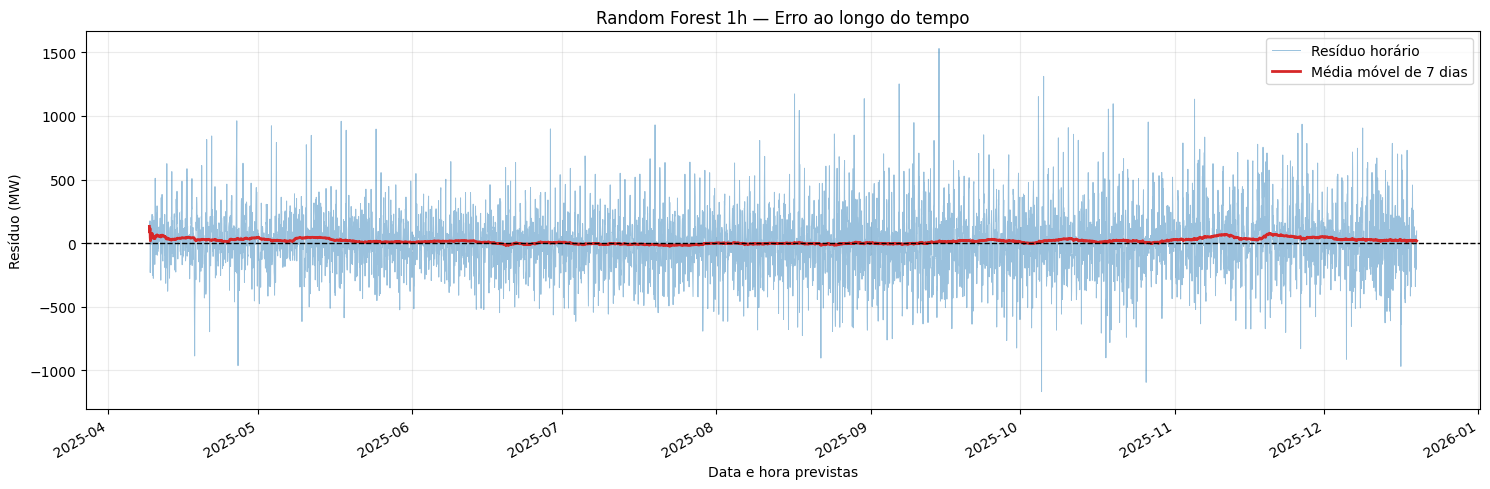

In [36]:
X_val_rf_1h = val[features_3]
pred_rf_1h = rf_model_3.predict(X_val_rf_1h)

residuos_rf_1h = pd.DataFrame({
    'timestamp_origem': pd.to_datetime(val['timestamp']),
    'observado': val[target_1],
    'previsto': pred_rf_1h,
}, index=val.index)
residuos_rf_1h['timestamp_previsto'] = (
    residuos_rf_1h['timestamp_origem'] + pd.Timedelta(hours=1)
)
residuos_rf_1h['residuo'] = (
    residuos_rf_1h['observado'] - residuos_rf_1h['previsto']
)
residuos_rf_1h = residuos_rf_1h.sort_values('timestamp_previsto')
media_movel_rf_1h = residuos_rf_1h['residuo'].rolling(24 * 7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(
    residuos_rf_1h['timestamp_previsto'], residuos_rf_1h['residuo'],
    color='tab:blue', linewidth=0.7, alpha=0.45, label='Resíduo horário',
)
ax.plot(
    residuos_rf_1h['timestamp_previsto'], media_movel_rf_1h,
    color='tab:red', linewidth=2, label='Média móvel de 7 dias',
)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('Random Forest 1h — Erro ao longo do tempo')
ax.set_xlabel('Data e hora previstas')
ax.set_ylabel('Resíduo (MW)')
ax.legend()
ax.grid(True, alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

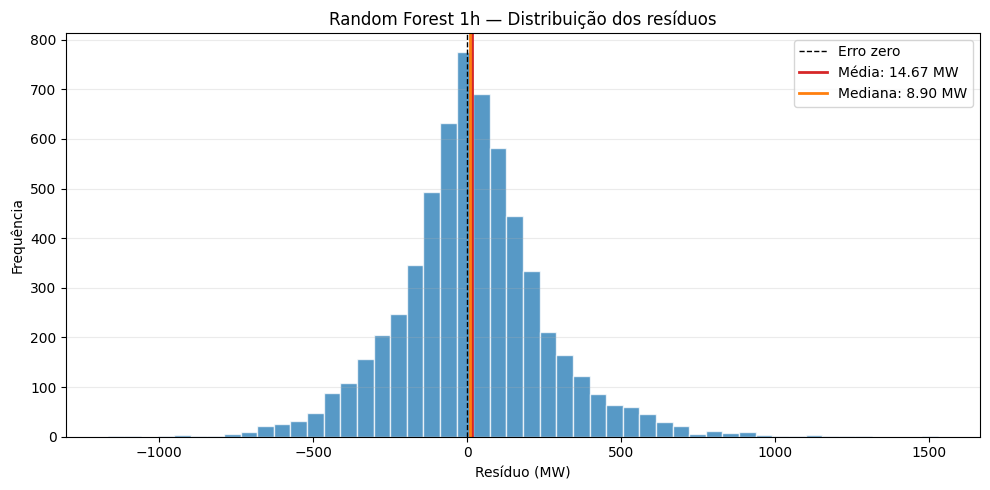

In [37]:
media_residuo_rf_1h = residuos_rf_1h['residuo'].mean()
mediana_residuo_rf_1h = residuos_rf_1h['residuo'].median()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    residuos_rf_1h['residuo'], bins=50,
    color='tab:blue', alpha=0.75, edgecolor='white',
)
ax.axvline(0, color='black', linewidth=1, linestyle='--', label='Erro zero')
ax.axvline(
    media_residuo_rf_1h, color='tab:red', linewidth=2,
    label=f'Média: {media_residuo_rf_1h:.2f} MW',
)
ax.axvline(
    mediana_residuo_rf_1h, color='tab:orange', linewidth=2,
    label=f'Mediana: {mediana_residuo_rf_1h:.2f} MW',
)
ax.set_title('Random Forest 1h — Distribuição dos resíduos')
ax.set_xlabel('Resíduo (MW)')
ax.set_ylabel('Frequência')
ax.legend()
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

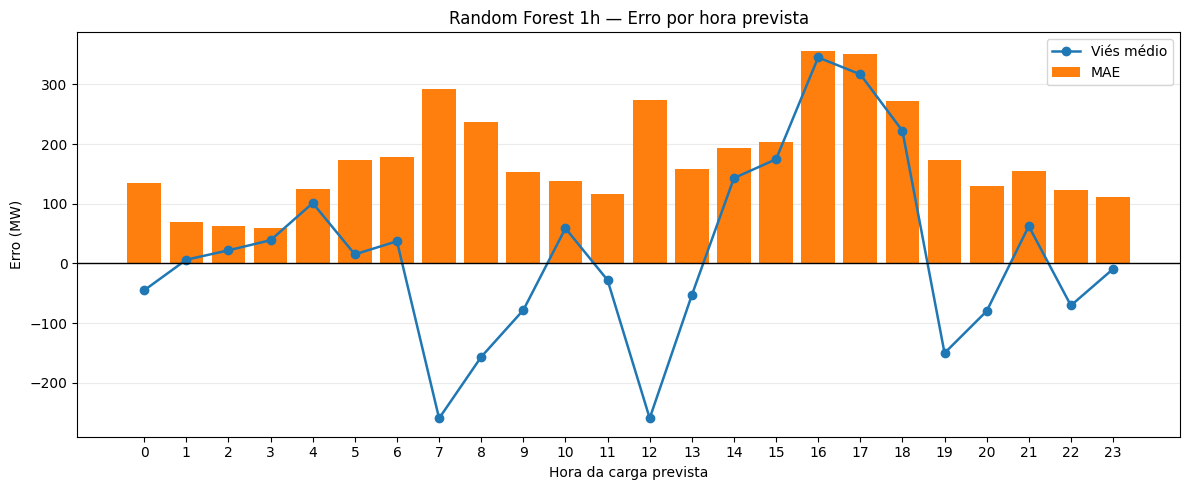

In [38]:
erro_por_hora_rf_1h = (
    residuos_rf_1h.assign(
        hora=residuos_rf_1h['timestamp_previsto'].dt.hour,
        erro_absoluto=residuos_rf_1h['residuo'].abs(),
    )
    .groupby('hora')
    .agg(mae_mw=('erro_absoluto', 'mean'), vies_mw=('residuo', 'mean'))
    .reindex(range(24))
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(erro_por_hora_rf_1h.index, erro_por_hora_rf_1h['mae_mw'], color='tab:orange', label='MAE')
ax.plot(
    erro_por_hora_rf_1h.index, erro_por_hora_rf_1h['vies_mw'],
    color='tab:blue', marker='o', linewidth=1.8, label='Viés médio',
)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(range(24))
ax.set_title('Random Forest 1h — Erro por hora prevista')
ax.set_xlabel('Hora da carga prevista')
ax.set_ylabel('Erro (MW)')
ax.legend()
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## 6h

In [39]:
rf_model_6_1 = avaliar_rf(
    features_1,
    target_6,
    'Random Forest - 6h'
)

rf_model_6_2 = avaliar_rf(
    features_2,
    target_6,
    'Random Forest - 6h + Carga'
)

rf_model_6_3 = avaliar_rf(
    features_3,
    target_6,
    'Random Forest - 6h + Lags'
)

rf_model_6_4 = avaliar_rf(
    features_4,
    target_6,
    'Random Forest - 6h + Rolling'
)

rf_model_6_5 = avaliar_rf(
    features_5,
    target_6,
    'Random Forest - 6h + Meteorologia'
)

Random Forest - 6h             | MAE: 1031.37 | RMSE: 1182.94 | MAPE: 7.74%
Random Forest - 6h + Carga     | MAE: 508.94 | RMSE: 656.90 | MAPE: 3.87%
Random Forest - 6h + Lags      | MAE: 488.31 | RMSE: 634.84 | MAPE: 3.72%
Random Forest - 6h + Rolling   | MAE: 380.62 | RMSE: 496.00 | MAPE: 2.94%
Random Forest - 6h + Meteorologia | MAE: 376.40 | RMSE: 492.70 | MAPE: 2.91%


In [40]:
importance = pd.DataFrame({
    'feature': features_5,
    'importance': rf_model_6_5.feature_importances_
})

importance = importance.sort_values(
    'importance',
    ascending=False
)

print(importance)

                   feature  importance
17           load_mean_24h    0.494844
1                 hour_cos    0.167810
8                  load_mw    0.106488
0                 hour_sin    0.070859
24  global_radiation_kj_m2    0.021877
2              weekday_sin    0.021663
6                  weekend    0.019938
3              weekday_cos    0.015873
25           temperature_c    0.012808
9              load_lag_1h    0.010095
20            load_std_24h    0.008805
12            load_lag_24h    0.008784
7      is_holiday_national    0.008579
5                month_cos    0.004847
19             load_std_6h    0.003886
21                 ramp_1h    0.003295
18             load_std_3h    0.002928
16            load_mean_6h    0.002291
11             load_lag_3h    0.002252
13            load_lag_48h    0.002103
23    pressure_station_hpa    0.001978
14           load_lag_168h    0.001592
15            load_mean_3h    0.001164
26            humidity_pct    0.001040
10             load_lag_2

### Diagnósticos do melhor modelo (6h)

Os gráficos usam o `rf_model_6_5` (**+ Meteorologia**), que apresentou o menor MAE na validação para o horizonte de 6h. O resíduo é calculado como **observado − previsto**.

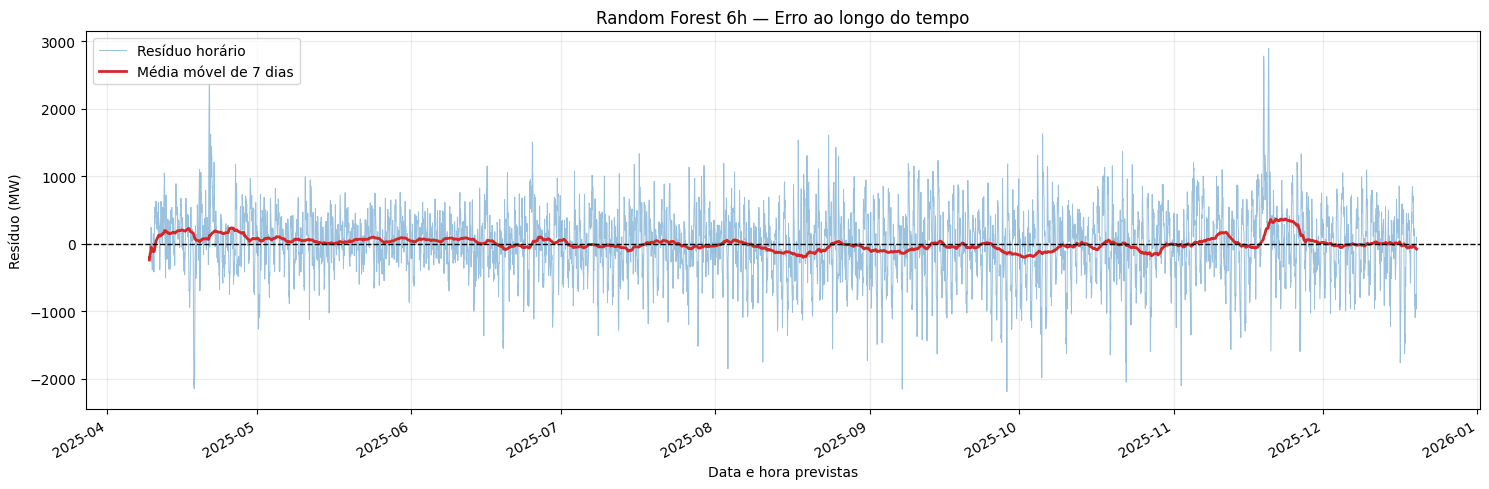

In [41]:
X_val_rf_6h = val[features_5]
pred_rf_6h = rf_model_6_5.predict(X_val_rf_6h)

residuos_rf_6h = pd.DataFrame({
    'timestamp_origem': pd.to_datetime(val['timestamp']),
    'observado': val[target_6],
    'previsto': pred_rf_6h,
}, index=val.index)
residuos_rf_6h['timestamp_previsto'] = (
    residuos_rf_6h['timestamp_origem'] + pd.Timedelta(hours=6)
)
residuos_rf_6h['residuo'] = (
    residuos_rf_6h['observado'] - residuos_rf_6h['previsto']
)
residuos_rf_6h = residuos_rf_6h.sort_values('timestamp_previsto')
media_movel_rf_6h = residuos_rf_6h['residuo'].rolling(24 * 7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(
    residuos_rf_6h['timestamp_previsto'], residuos_rf_6h['residuo'],
    color='tab:blue', linewidth=0.7, alpha=0.45, label='Resíduo horário',
)
ax.plot(
    residuos_rf_6h['timestamp_previsto'], media_movel_rf_6h,
    color='tab:red', linewidth=2, label='Média móvel de 7 dias',
)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('Random Forest 6h — Erro ao longo do tempo')
ax.set_xlabel('Data e hora previstas')
ax.set_ylabel('Resíduo (MW)')
ax.legend()
ax.grid(True, alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

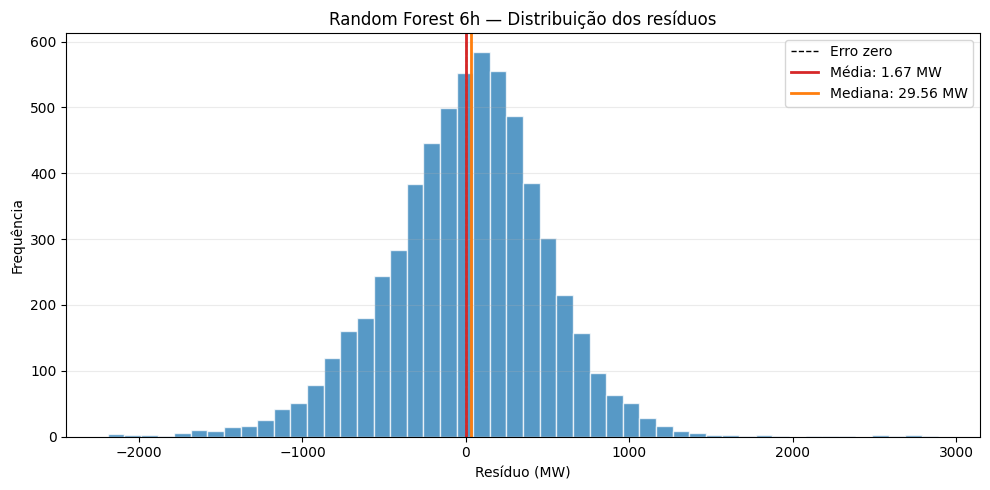

In [42]:
media_residuo_rf_6h = residuos_rf_6h['residuo'].mean()
mediana_residuo_rf_6h = residuos_rf_6h['residuo'].median()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    residuos_rf_6h['residuo'], bins=50,
    color='tab:blue', alpha=0.75, edgecolor='white',
)
ax.axvline(0, color='black', linewidth=1, linestyle='--', label='Erro zero')
ax.axvline(
    media_residuo_rf_6h, color='tab:red', linewidth=2,
    label=f'Média: {media_residuo_rf_6h:.2f} MW',
)
ax.axvline(
    mediana_residuo_rf_6h, color='tab:orange', linewidth=2,
    label=f'Mediana: {mediana_residuo_rf_6h:.2f} MW',
)
ax.set_title('Random Forest 6h — Distribuição dos resíduos')
ax.set_xlabel('Resíduo (MW)')
ax.set_ylabel('Frequência')
ax.legend()
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

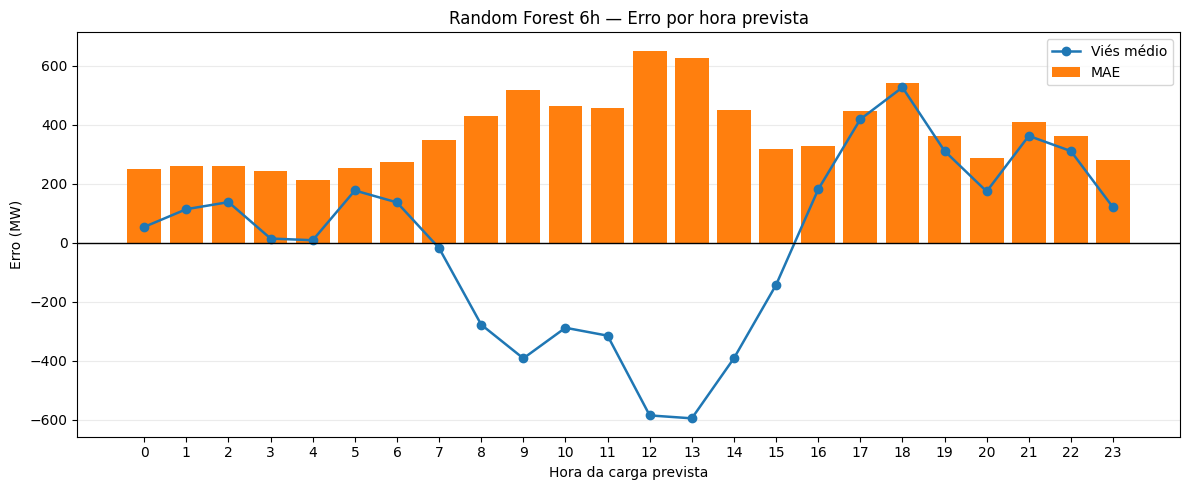

In [43]:
erro_por_hora_rf_6h = (
    residuos_rf_6h.assign(
        hora=residuos_rf_6h['timestamp_previsto'].dt.hour,
        erro_absoluto=residuos_rf_6h['residuo'].abs(),
    )
    .groupby('hora')
    .agg(mae_mw=('erro_absoluto', 'mean'), vies_mw=('residuo', 'mean'))
    .reindex(range(24))
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(erro_por_hora_rf_6h.index, erro_por_hora_rf_6h['mae_mw'], color='tab:orange', label='MAE')
ax.plot(
    erro_por_hora_rf_6h.index, erro_por_hora_rf_6h['vies_mw'],
    color='tab:blue', marker='o', linewidth=1.8, label='Viés médio',
)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(range(24))
ax.set_title('Random Forest 6h — Erro por hora prevista')
ax.set_xlabel('Hora da carga prevista')
ax.set_ylabel('Erro (MW)')
ax.legend()
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## 24h

In [44]:
rf_model_24_1 = avaliar_rf(
    features_1,
    target_24,
    'Random Forest - 24h'
)

rf_model_24_2 = avaliar_rf(
    features_2,
    target_24,
    'Random Forest - 24h + Carga'
)

rf_model_24_3 = avaliar_rf(
    features_3,
    target_24,
    'Random Forest - 24h + Lags'
)

rf_model_24_4 = avaliar_rf(
    features_4,
    target_24,
    'Random Forest - 24h + Rolling'
)

rf_model_24_5 = avaliar_rf(
    features_5,
    target_24,
    'Random Forest - 24h + Meteorologia'
)

Random Forest - 24h            | MAE: 1036.84 | RMSE: 1188.68 | MAPE: 7.76%
Random Forest - 24h + Carga    | MAE: 312.50 | RMSE: 441.54 | MAPE: 2.40%
Random Forest - 24h + Lags     | MAE: 308.13 | RMSE: 434.16 | MAPE: 2.37%
Random Forest - 24h + Rolling  | MAE: 311.60 | RMSE: 439.19 | MAPE: 2.40%
Random Forest - 24h + Meteorologia | MAE: 312.12 | RMSE: 441.62 | MAPE: 2.40%


In [45]:
importance = pd.DataFrame({
    'feature': features_3,
    'importance': rf_model_24_3.feature_importances_
})

importance = importance.sort_values(
    'importance',
    ascending=False
)

print(importance)

                feature  importance
8               load_mw    0.736475
13         load_lag_48h    0.090434
2           weekday_sin    0.072333
1              hour_cos    0.034936
3           weekday_cos    0.026057
12         load_lag_24h    0.009882
14        load_lag_168h    0.007463
9           load_lag_1h    0.007435
0              hour_sin    0.003723
10          load_lag_2h    0.003422
11          load_lag_3h    0.003361
4             month_sin    0.002016
5             month_cos    0.001305
6               weekend    0.000632
7   is_holiday_national    0.000526


### Diagnósticos do melhor modelo (24h)

Os gráficos usam o `rf_model_24_3` (**+ Lags**), que apresentou o menor MAE na validação para o horizonte de 24h. O resíduo é calculado como **observado − previsto**.

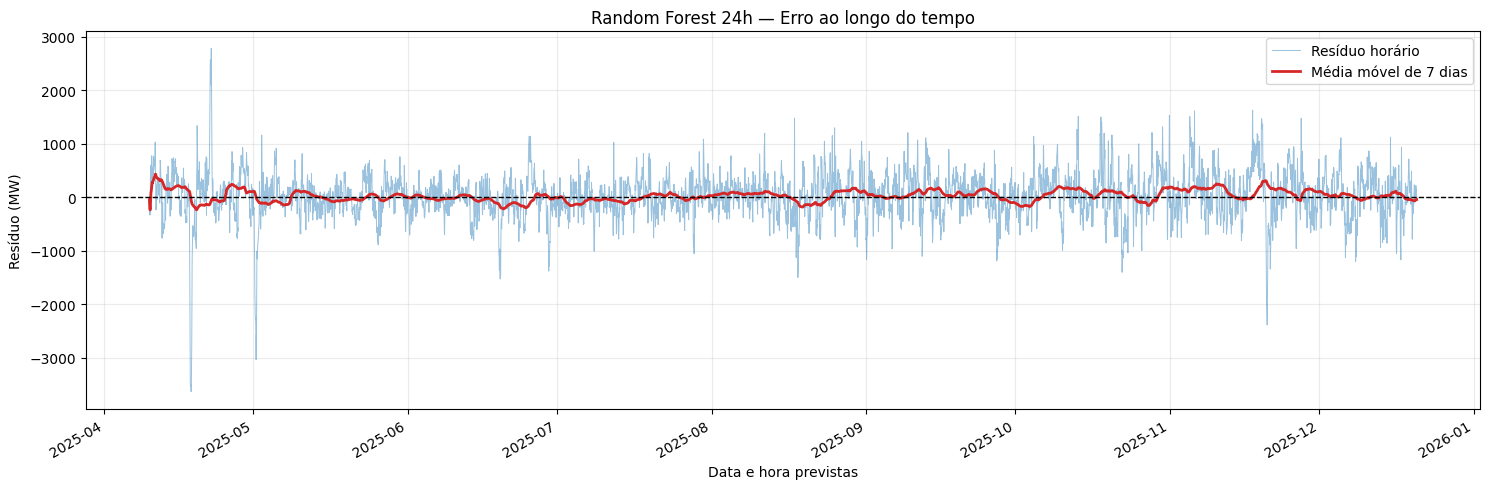

In [46]:
X_val_rf_24h = val[features_3]
pred_rf_24h = rf_model_24_3.predict(X_val_rf_24h)

residuos_rf_24h = pd.DataFrame({
    'timestamp_origem': pd.to_datetime(val['timestamp']),
    'observado': val[target_24],
    'previsto': pred_rf_24h,
}, index=val.index)
residuos_rf_24h['timestamp_previsto'] = (
    residuos_rf_24h['timestamp_origem'] + pd.Timedelta(hours=24)
)
residuos_rf_24h['residuo'] = (
    residuos_rf_24h['observado'] - residuos_rf_24h['previsto']
)
residuos_rf_24h = residuos_rf_24h.sort_values('timestamp_previsto')
media_movel_rf_24h = residuos_rf_24h['residuo'].rolling(24 * 7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(
    residuos_rf_24h['timestamp_previsto'], residuos_rf_24h['residuo'],
    color='tab:blue', linewidth=0.7, alpha=0.45, label='Resíduo horário',
)
ax.plot(
    residuos_rf_24h['timestamp_previsto'], media_movel_rf_24h,
    color='tab:red', linewidth=2, label='Média móvel de 7 dias',
)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('Random Forest 24h — Erro ao longo do tempo')
ax.set_xlabel('Data e hora previstas')
ax.set_ylabel('Resíduo (MW)')
ax.legend()
ax.grid(True, alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

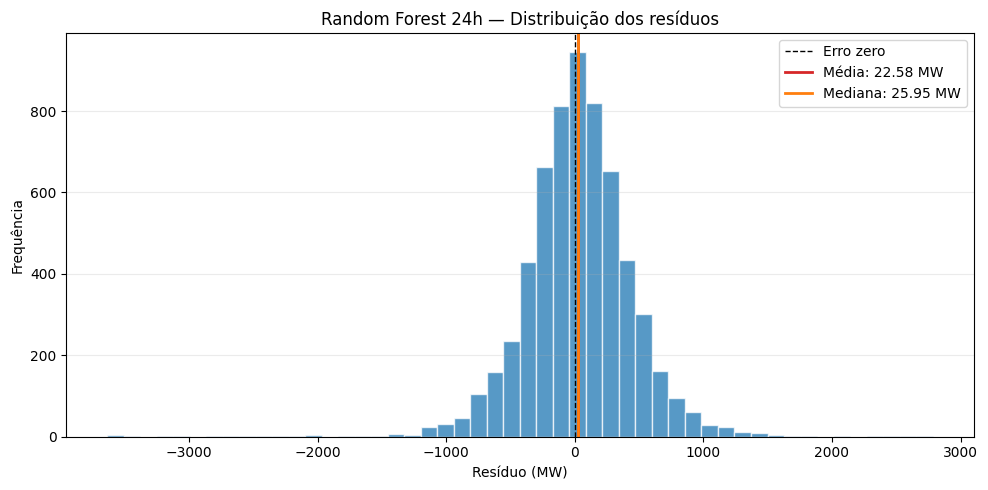

In [47]:
media_residuo_rf_24h = residuos_rf_24h['residuo'].mean()
mediana_residuo_rf_24h = residuos_rf_24h['residuo'].median()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    residuos_rf_24h['residuo'], bins=50,
    color='tab:blue', alpha=0.75, edgecolor='white',
)
ax.axvline(0, color='black', linewidth=1, linestyle='--', label='Erro zero')
ax.axvline(
    media_residuo_rf_24h, color='tab:red', linewidth=2,
    label=f'Média: {media_residuo_rf_24h:.2f} MW',
)
ax.axvline(
    mediana_residuo_rf_24h, color='tab:orange', linewidth=2,
    label=f'Mediana: {mediana_residuo_rf_24h:.2f} MW',
)
ax.set_title('Random Forest 24h — Distribuição dos resíduos')
ax.set_xlabel('Resíduo (MW)')
ax.set_ylabel('Frequência')
ax.legend()
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

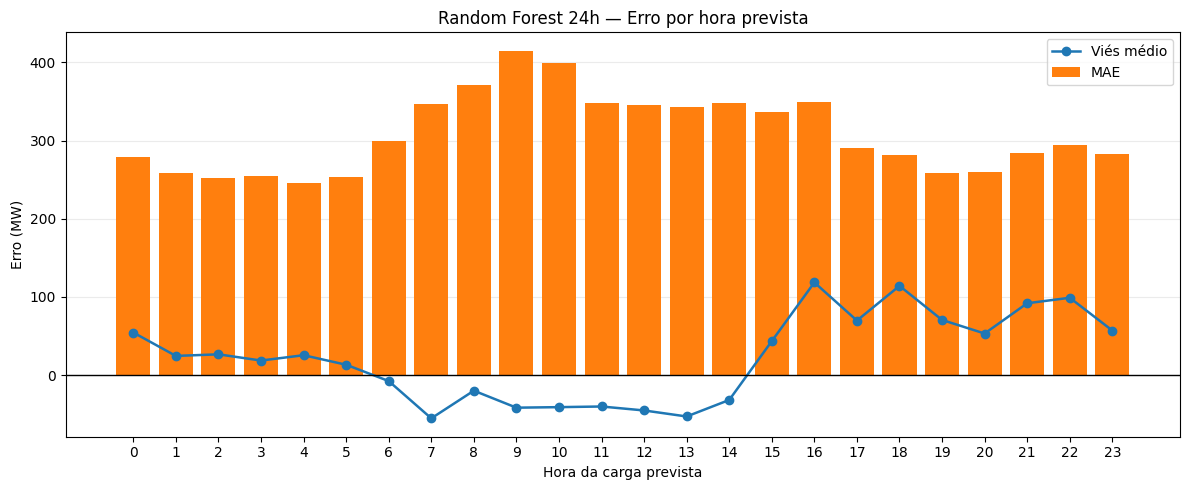

In [48]:
erro_por_hora_rf_24h = (
    residuos_rf_24h.assign(
        hora=residuos_rf_24h['timestamp_previsto'].dt.hour,
        erro_absoluto=residuos_rf_24h['residuo'].abs(),
    )
    .groupby('hora')
    .agg(mae_mw=('erro_absoluto', 'mean'), vies_mw=('residuo', 'mean'))
    .reindex(range(24))
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(erro_por_hora_rf_24h.index, erro_por_hora_rf_24h['mae_mw'], color='tab:orange', label='MAE')
ax.plot(
    erro_por_hora_rf_24h.index, erro_por_hora_rf_24h['vies_mw'],
    color='tab:blue', marker='o', linewidth=1.8, label='Viés médio',
)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(range(24))
ax.set_title('Random Forest 24h — Erro por hora prevista')
ax.set_xlabel('Hora da carga prevista')
ax.set_ylabel('Erro (MW)')
ax.legend()
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

# XGBoost

## Modelo BASE

In [57]:
def avaliar_xgboost(features, target, name):
  X_train = train[features]
  y_train = train[target]

  X_val = val[features]
  y_val = val[target]

  model = XGBRegressor(
      objective='reg:squarederror',
      n_estimators=300,
      learning_rate = 0.05,
      max_depth = 5,
      random_state=42
  )

  model.fit(X_train, y_train)

  pred = model.predict(X_val)

  mae = mean_absolute_error(y_val, pred)

  rmse = np.sqrt(
        mean_squared_error(y_val, pred)
    )

  mape = mean_absolute_percentage_error(
        y_val,
        pred
    ) * 100

  print(
        f'{name:<32} | '
        f'MAE: {mae:.2f} | '
        f'RMSE: {rmse:.2f} | '
        f'MAPE: {mape:.2f}%'
    )

  return model

## 1h

In [58]:
xgb_1 = avaliar_xgboost(
    features_1,
    target_1,
    'XGBoost - 1h'
)

xgb_2 = avaliar_xgboost(
    features_2,
    target_1,
    'XGBoost - 1h + Carga'
)

xgb_3 = avaliar_xgboost(
    features_3,
    target_1,
    'XGBoost - 1h + Lags'
)

xgb_4 = avaliar_xgboost(
    features_4,
    target_1,
    'XGBoost - 1h + Rolling'
)

xgb_5 = avaliar_xgboost(
    features_5,
    target_1,
    'XGBoost - 1h + Meteorologia'
)

XGBoost - 1h                     | MAE: 1029.41 | RMSE: 1176.87 | MAPE: 7.73%
XGBoost - 1h + Carga             | MAE: 158.42 | RMSE: 230.65 | MAPE: 1.22%
XGBoost - 1h + Lags              | MAE: 149.51 | RMSE: 213.83 | MAPE: 1.15%
XGBoost - 1h + Rolling           | MAE: 147.28 | RMSE: 205.90 | MAPE: 1.13%
XGBoost - 1h + Meteorologia      | MAE: 148.81 | RMSE: 208.50 | MAPE: 1.14%


In [61]:
importance = pd.DataFrame({
    'feature': features_4,
    'importance': xgb_4.feature_importances_
})

importance = importance.sort_values(
    'importance',
    ascending=False
)

print(importance)

                feature  importance
8               load_mw    0.916218
1              hour_cos    0.023603
0              hour_sin    0.011561
2           weekday_sin    0.006855
9           load_lag_1h    0.006395
17        load_mean_24h    0.005552
5             month_cos    0.005112
21              ramp_1h    0.002955
19          load_std_6h    0.002927
7   is_holiday_national    0.002775
3           weekday_cos    0.002139
13         load_lag_48h    0.002025
20         load_std_24h    0.001945
11          load_lag_3h    0.001788
16         load_mean_6h    0.001523
10          load_lag_2h    0.001507
15         load_mean_3h    0.001248
4             month_sin    0.001191
18          load_std_3h    0.001073
12         load_lag_24h    0.000820
14        load_lag_168h    0.000790
6               weekend    0.000000


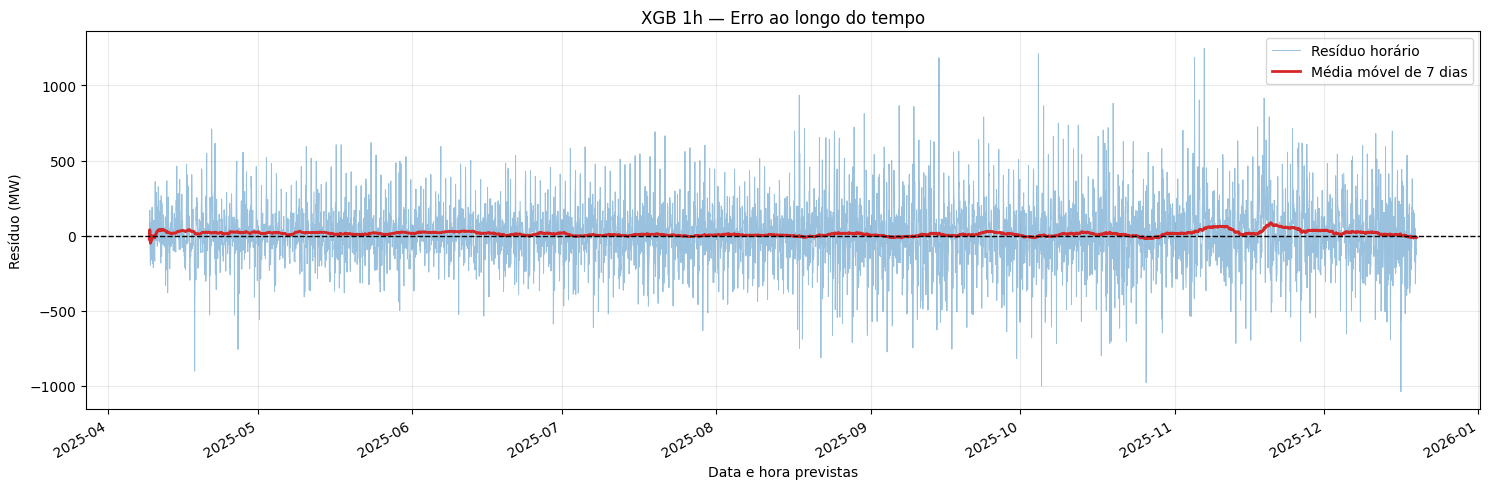

In [63]:
X_val_xgb_1h = val[features_4]
pred_xgb_1h = xgb_4.predict(X_val_xgb_1h)

residuos_xgb_1h = pd.DataFrame({
    'timestamp_origem': pd.to_datetime(val['timestamp']),
    'observado': val[target_1],
    'previsto': pred_xgb_1h,
}, index=val.index)
residuos_xgb_1h['timestamp_previsto'] = (
    residuos_xgb_1h['timestamp_origem'] + pd.Timedelta(hours=1)
)
residuos_xgb_1h['residuo'] = (
    residuos_xgb_1h['observado'] - residuos_xgb_1h['previsto']
)
residuos_xgb_1h = residuos_xgb_1h.sort_values('timestamp_previsto')
media_movel_xgb_1h = residuos_xgb_1h['residuo'].rolling(24 * 7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(
    residuos_xgb_1h['timestamp_previsto'], residuos_xgb_1h['residuo'],
    color='tab:blue', linewidth=0.7, alpha=0.45, label='Resíduo horário',
)
ax.plot(
    residuos_xgb_1h['timestamp_previsto'], media_movel_xgb_1h,
    color='tab:red', linewidth=2, label='Média móvel de 7 dias',
)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('XGB 1h — Erro ao longo do tempo')
ax.set_xlabel('Data e hora previstas')
ax.set_ylabel('Resíduo (MW)')
ax.legend()
ax.grid(True, alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

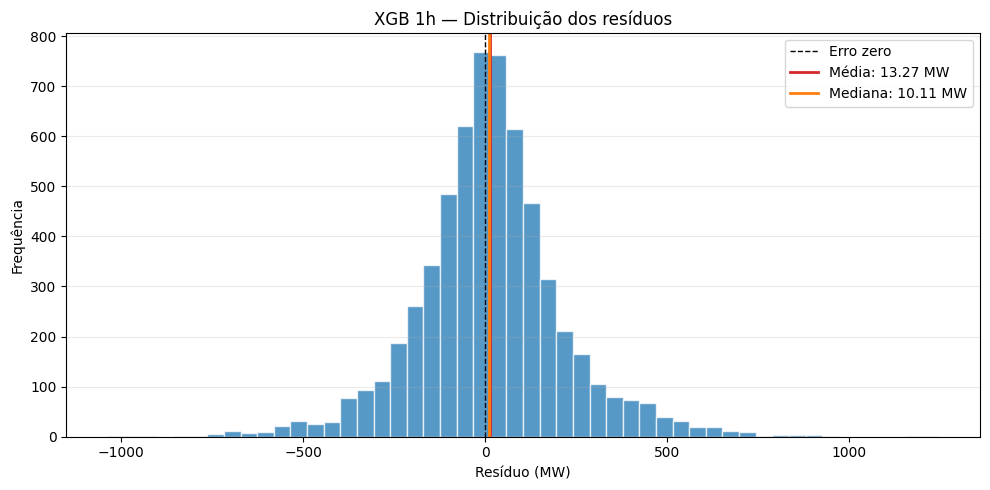

In [64]:
media_residuo_xgb_1h = residuos_xgb_1h['residuo'].mean()
mediana_residuo_xgb_1h = residuos_xgb_1h['residuo'].median()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    residuos_xgb_1h['residuo'], bins=50,
    color='tab:blue', alpha=0.75, edgecolor='white',
)
ax.axvline(0, color='black', linewidth=1, linestyle='--', label='Erro zero')
ax.axvline(
    media_residuo_xgb_1h, color='tab:red', linewidth=2,
    label=f'Média: {media_residuo_xgb_1h:.2f} MW',
)
ax.axvline(
    mediana_residuo_xgb_1h, color='tab:orange', linewidth=2,
    label=f'Mediana: {mediana_residuo_xgb_1h:.2f} MW',
)
ax.set_title('XGB 1h — Distribuição dos resíduos')
ax.set_xlabel('Resíduo (MW)')
ax.set_ylabel('Frequência')
ax.legend()
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

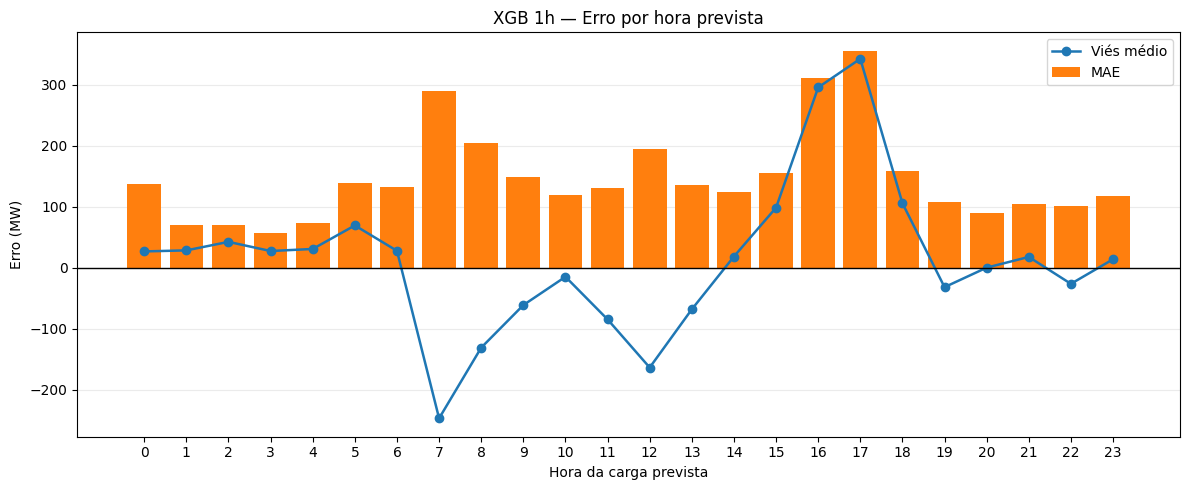

In [65]:
erro_por_hora_xgb_1h = (
    residuos_xgb_1h.assign(
        hora=residuos_xgb_1h['timestamp_previsto'].dt.hour,
        erro_absoluto=residuos_xgb_1h['residuo'].abs(),
    )
    .groupby('hora')
    .agg(mae_mw=('erro_absoluto', 'mean'), vies_mw=('residuo', 'mean'))
    .reindex(range(24))
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(erro_por_hora_xgb_1h.index, erro_por_hora_xgb_1h['mae_mw'], color='tab:orange', label='MAE')
ax.plot(
    erro_por_hora_xgb_1h.index, erro_por_hora_xgb_1h['vies_mw'],
    color='tab:blue', marker='o', linewidth=1.8, label='Viés médio',
)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(range(24))
ax.set_title('XGB 1h — Erro por hora prevista')
ax.set_xlabel('Hora da carga prevista')
ax.set_ylabel('Erro (MW)')
ax.legend()
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## 6h

In [59]:
xgb_6_1 = avaliar_xgboost(
    features_1,
    target_6,
    'XGBoost - 6h'
)

xgb_6_2 = avaliar_xgboost(
    features_2,
    target_6,
    'XGBoost - 6h + Carga'
)

xgb_6_3 = avaliar_xgboost(
    features_3,
    target_6,
    'XGBoost - 6h + Lags'
)

xgb_6_4 = avaliar_xgboost(
    features_4,
    target_6,
    'XGBoost - 6h + Rolling'
)

xgb_6_5 = avaliar_xgboost(
    features_5,
    target_6,
    'XGBoost - 6h + Meteorologia'
)

XGBoost - 6h                     | MAE: 1030.88 | RMSE: 1178.81 | MAPE: 7.74%
XGBoost - 6h + Carga             | MAE: 513.51 | RMSE: 660.85 | MAPE: 3.91%
XGBoost - 6h + Lags              | MAE: 501.70 | RMSE: 645.85 | MAPE: 3.83%
XGBoost - 6h + Rolling           | MAE: 375.03 | RMSE: 485.62 | MAPE: 2.91%
XGBoost - 6h + Meteorologia      | MAE: 369.07 | RMSE: 477.00 | MAPE: 2.86%


In [70]:
importance = pd.DataFrame({
    'feature': features_5,
    'importance': xgb_6_5.feature_importances_
})

importance = importance.sort_values(
    'importance',
    ascending=False
)

print(importance)

                   feature  importance
17           load_mean_24h    0.299351
1                 hour_cos    0.164496
8                  load_mw    0.095218
2              weekday_sin    0.063214
0                 hour_sin    0.062088
24  global_radiation_kj_m2    0.056405
3              weekday_cos    0.048856
9              load_lag_1h    0.036425
7      is_holiday_national    0.034178
21                 ramp_1h    0.031844
25           temperature_c    0.022355
19             load_std_6h    0.012164
20            load_std_24h    0.012085
5                month_cos    0.010555
11             load_lag_3h    0.007672
12            load_lag_24h    0.007480
13            load_lag_48h    0.004756
26            humidity_pct    0.004513
16            load_mean_6h    0.004322
18             load_std_3h    0.003882
23    pressure_station_hpa    0.003775
15            load_mean_3h    0.002696
4                month_sin    0.002654
14           load_lag_168h    0.002085
22        precipitation_m

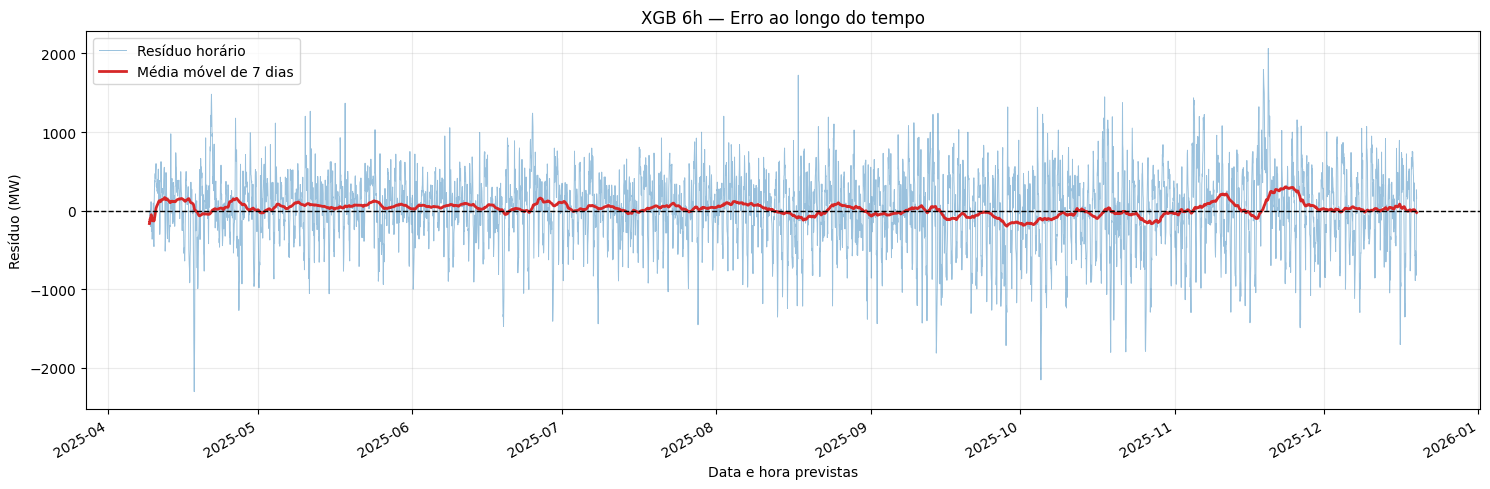

In [71]:
X_val_xgb_6h = val[features_5]
pred_xgb_6h = xgb_6_5.predict(X_val_xgb_6h)

residuos_xgb_6h = pd.DataFrame({
    'timestamp_origem': pd.to_datetime(val['timestamp']),
    'observado': val[target_6],
    'previsto': pred_xgb_6h,
}, index=val.index)
residuos_xgb_6h['timestamp_previsto'] = (
    residuos_xgb_6h['timestamp_origem'] + pd.Timedelta(hours=1)
)
residuos_xgb_6h['residuo'] = (
    residuos_xgb_6h['observado'] - residuos_xgb_6h['previsto']
)
residuos_xgb_6h = residuos_xgb_6h.sort_values('timestamp_previsto')
media_movel_xgb_6h = residuos_xgb_6h['residuo'].rolling(24 * 7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(
    residuos_xgb_6h['timestamp_previsto'], residuos_xgb_6h['residuo'],
    color='tab:blue', linewidth=0.7, alpha=0.45, label='Resíduo horário',
)
ax.plot(
    residuos_xgb_6h['timestamp_previsto'], media_movel_xgb_6h,
    color='tab:red', linewidth=2, label='Média móvel de 7 dias',
)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('XGB 6h — Erro ao longo do tempo')
ax.set_xlabel('Data e hora previstas')
ax.set_ylabel('Resíduo (MW)')
ax.legend()
ax.grid(True, alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

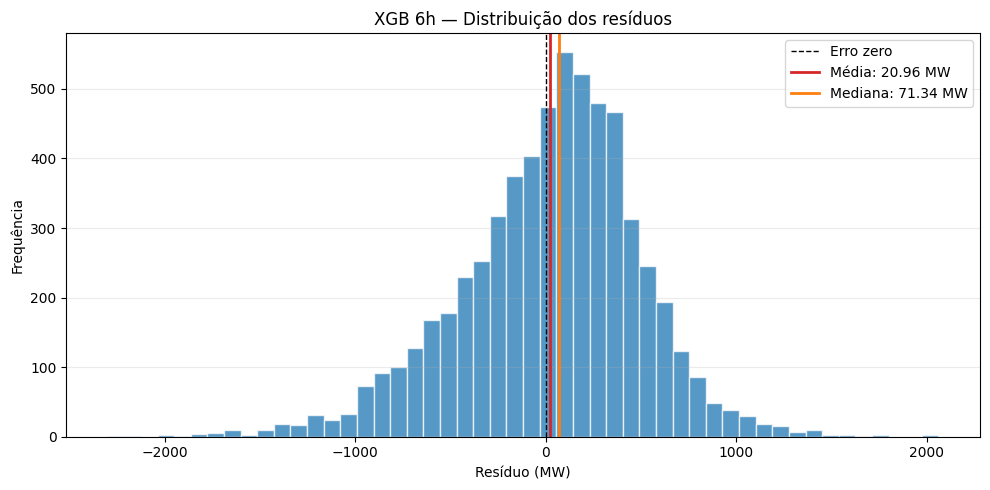

In [72]:
media_residuo_xgb_6h = residuos_xgb_6h['residuo'].mean()
mediana_residuo_xgb_6h = residuos_xgb_6h['residuo'].median()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    residuos_xgb_6h['residuo'], bins=50,
    color='tab:blue', alpha=0.75, edgecolor='white',
)
ax.axvline(0, color='black', linewidth=1, linestyle='--', label='Erro zero')
ax.axvline(
    media_residuo_xgb_6h, color='tab:red', linewidth=2,
    label=f'Média: {media_residuo_xgb_6h:.2f} MW',
)
ax.axvline(
    mediana_residuo_xgb_6h, color='tab:orange', linewidth=2,
    label=f'Mediana: {mediana_residuo_xgb_6h:.2f} MW',
)
ax.set_title('XGB 6h — Distribuição dos resíduos')
ax.set_xlabel('Resíduo (MW)')
ax.set_ylabel('Frequência')
ax.legend()
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

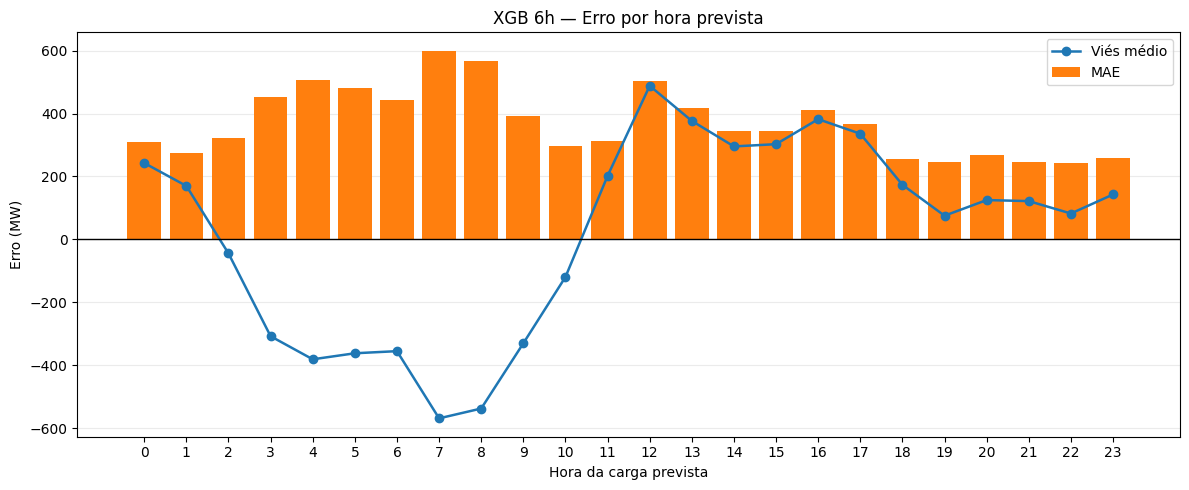

In [74]:
erro_por_hora_xgb_6h = (
    residuos_xgb_6h.assign(
        hora=residuos_xgb_6h['timestamp_previsto'].dt.hour,
        erro_absoluto=residuos_xgb_6h['residuo'].abs(),
    )
    .groupby('hora')
    .agg(mae_mw=('erro_absoluto', 'mean'), vies_mw=('residuo', 'mean'))
    .reindex(range(24))
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(erro_por_hora_xgb_6h.index, erro_por_hora_xgb_6h['mae_mw'], color='tab:orange', label='MAE')
ax.plot(
    erro_por_hora_xgb_6h.index, erro_por_hora_xgb_6h['vies_mw'],
    color='tab:blue', marker='o', linewidth=1.8, label='Viés médio',
)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(range(24))
ax.set_title('XGB 6h — Erro por hora prevista')
ax.set_xlabel('Hora da carga prevista')
ax.set_ylabel('Erro (MW)')
ax.legend()
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## 24h

In [60]:
xgb_24_1 = avaliar_xgboost(
    features_1,
    target_24,
    'XGBoost - 24h'
)

xgb_24_2 = avaliar_xgboost(
    features_2,
    target_24,
    'XGBoost - 24h + Carga'
)

xgb_24_3 = avaliar_xgboost(
    features_3,
    target_24,
    'XGBoost - 24h + Lags'
)

xgb_24_4 = avaliar_xgboost(
    features_4,
    target_24,
    'XGBoost - 24h + Rolling'
)

xgb_24_5 = avaliar_xgboost(
    features_5,
    target_24,
    'XGBoost - 24h + Meteorologia'
)

XGBoost - 24h                    | MAE: 1038.96 | RMSE: 1191.03 | MAPE: 7.78%
XGBoost - 24h + Carga            | MAE: 311.50 | RMSE: 433.78 | MAPE: 2.39%
XGBoost - 24h + Lags             | MAE: 303.44 | RMSE: 418.48 | MAPE: 2.33%
XGBoost - 24h + Rolling          | MAE: 306.92 | RMSE: 426.31 | MAPE: 2.37%
XGBoost - 24h + Meteorologia     | MAE: 302.67 | RMSE: 422.68 | MAPE: 2.33%


In [75]:
importance = pd.DataFrame({
    'feature': features_3,
    'importance': xgb_24_3.feature_importances_
})

importance = importance.sort_values(
    'importance',
    ascending=False
)

print(importance)

                feature  importance
8               load_mw    0.652469
13         load_lag_48h    0.078996
2           weekday_sin    0.077102
3           weekday_cos    0.056086
1              hour_cos    0.042600
14        load_lag_168h    0.026389
9           load_lag_1h    0.020561
7   is_holiday_national    0.010081
12         load_lag_24h    0.008084
10          load_lag_2h    0.007518
0              hour_sin    0.006764
11          load_lag_3h    0.006064
4             month_sin    0.003648
5             month_cos    0.003639
6               weekend    0.000000


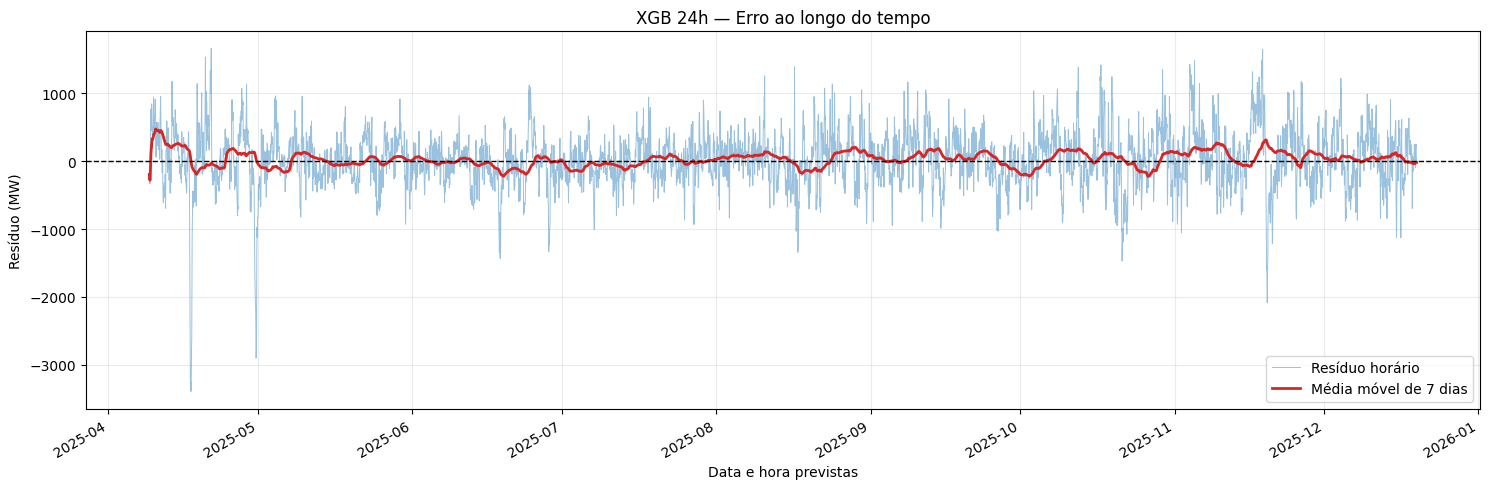

In [76]:
X_val_xgb_24h = val[features_3]
pred_xgb_24h = xgb_24_3.predict(X_val_xgb_24h)

residuos_xgb_24h = pd.DataFrame({
    'timestamp_origem': pd.to_datetime(val['timestamp']),
    'observado': val[target_24],
    'previsto': pred_xgb_24h,
}, index=val.index)
residuos_xgb_24h['timestamp_previsto'] = (
    residuos_xgb_24h['timestamp_origem'] + pd.Timedelta(hours=1)
)
residuos_xgb_24h['residuo'] = (
    residuos_xgb_24h['observado'] - residuos_xgb_24h['previsto']
)
residuos_xgb_24h = residuos_xgb_24h.sort_values('timestamp_previsto')
media_movel_xgb_24h = residuos_xgb_24h['residuo'].rolling(24 * 7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(
    residuos_xgb_24h['timestamp_previsto'], residuos_xgb_24h['residuo'],
    color='tab:blue', linewidth=0.7, alpha=0.45, label='Resíduo horário',
)
ax.plot(
    residuos_xgb_24h['timestamp_previsto'], media_movel_xgb_24h,
    color='tab:red', linewidth=2, label='Média móvel de 7 dias',
)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('XGB 24h — Erro ao longo do tempo')
ax.set_xlabel('Data e hora previstas')
ax.set_ylabel('Resíduo (MW)')
ax.legend()
ax.grid(True, alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

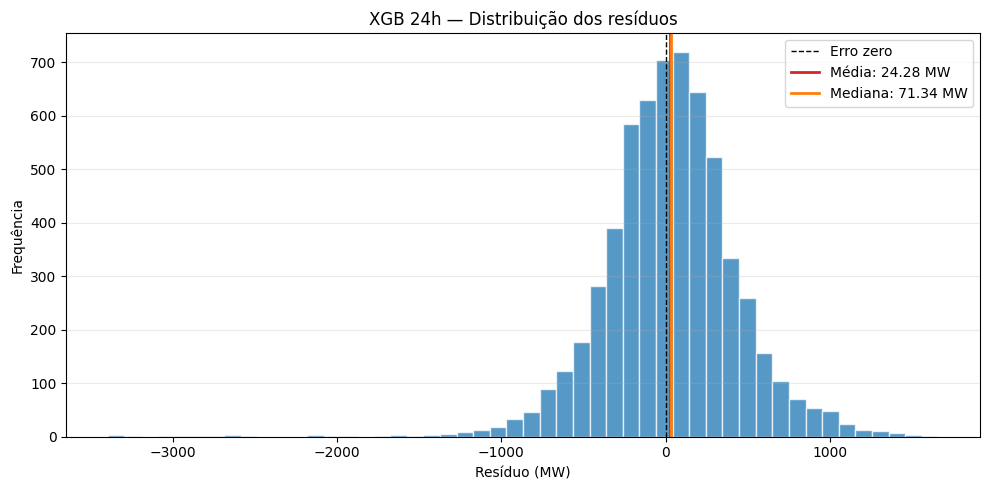

In [79]:
media_residuo_xgb_24h = residuos_xgb_24h['residuo'].mean()
mediana_residuo_xgb_24h = residuos_xgb_24h['residuo'].median()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    residuos_xgb_24h['residuo'], bins=50,
    color='tab:blue', alpha=0.75, edgecolor='white',
)
ax.axvline(0, color='black', linewidth=1, linestyle='--', label='Erro zero')
ax.axvline(
    media_residuo_xgb_24h, color='tab:red', linewidth=2,
    label=f'Média: {media_residuo_xgb_24h:.2f} MW',
)
ax.axvline(
    mediana_residuo_xgb_24h, color='tab:orange', linewidth=2,
    label=f'Mediana: {mediana_residuo_xgb_6h:.2f} MW',
)
ax.set_title('XGB 24h — Distribuição dos resíduos')
ax.set_xlabel('Resíduo (MW)')
ax.set_ylabel('Frequência')
ax.legend()
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

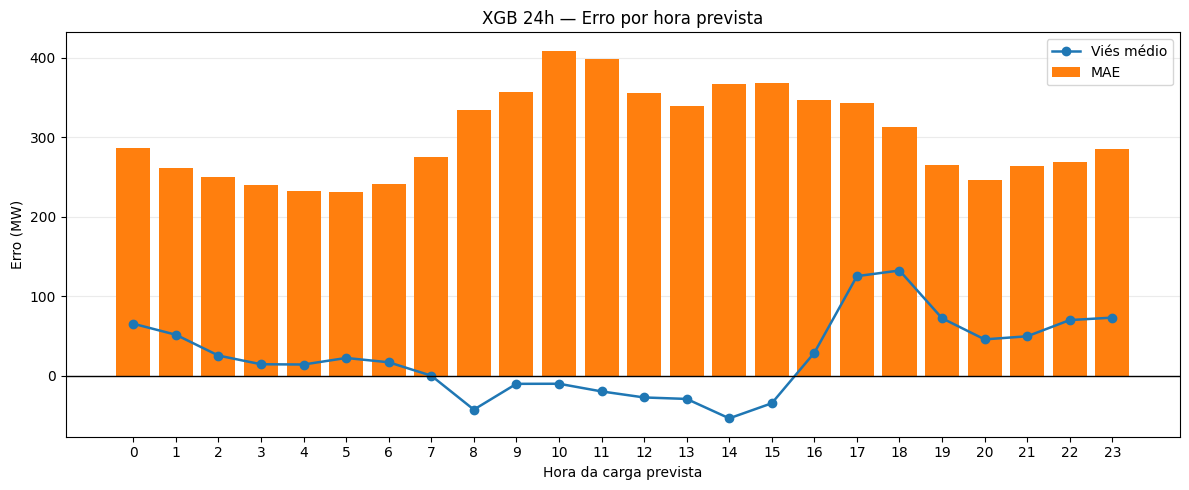

In [80]:
erro_por_hora_xgb_24h = (
    residuos_xgb_24h.assign(
        hora=residuos_xgb_24h['timestamp_previsto'].dt.hour,
        erro_absoluto=residuos_xgb_24h['residuo'].abs(),
    )
    .groupby('hora')
    .agg(mae_mw=('erro_absoluto', 'mean'), vies_mw=('residuo', 'mean'))
    .reindex(range(24))
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(erro_por_hora_xgb_24h.index, erro_por_hora_xgb_24h['mae_mw'], color='tab:orange', label='MAE')
ax.plot(
    erro_por_hora_xgb_24h.index, erro_por_hora_xgb_24h['vies_mw'],
    color='tab:blue', marker='o', linewidth=1.8, label='Viés médio',
)
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(range(24))
ax.set_title('XGB 24h — Erro por hora prevista')
ax.set_xlabel('Hora da carga prevista')
ax.set_ylabel('Erro (MW)')
ax.legend()
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()